In [4]:
# ===================================================================
# THESIS: TabNet Predictive Performance & Interpretability Validation
# PAPER: TabNet-LSTM Ensemble with Elastic Net Stacking for IHSG
# VERSION: 6.0 - Compact & Focused (1-Day Horizon Only)
# ===================================================================

import warnings
warnings.filterwarnings('ignore')

import os, time, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Tuple, Dict, Optional
import joblib, json

import yfinance as yf
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, ElasticNet

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from pytorch_tabnet.tab_model import TabNetRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)


# ===================================================================
# GLOBAL CONFIG
# ===================================================================

class Config:
    SEED = 42
    NUM_CORES = os.cpu_count() or 1
    NUM_THREADS = max(1, NUM_CORES // 2)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DTYPE = torch.float32
    
    START_DATE = "2010-01-01"
    FRED_API_KEY = 'eceded1789eb5832d183da55288beb80'
    TRAIN_SPLIT = 0.8
    N_SPLITS = 3
    
    HORIZON = 1  # 1-day only
    TIMESTEPS = 60  # Will be optimized
    
    TRANSACTION_COST = 0.001
    RISK_FREE_RATE = 0.06
    
    OUTPUT_DIR = 'exports-19-oktober-2025'
    for subdir in ['data', 'models', 'visualizations', 'eda', 'meta_learner']:
        os.makedirs(f'{OUTPUT_DIR}/{subdir}', exist_ok=True)

config = Config()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
torch.set_num_threads(config.NUM_THREADS)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['font.size'] = 10

print("="*70)
print("IHSG FORECASTING: TabNet Focus (1-Day Horizon)")
print("="*70)
print(f"Device: {config.DEVICE} | Threads: {config.NUM_THREADS}")
print("="*70)

# ===================================================================
# SECTION 1: DATA ACQUISITION
# ===================================================================

print("\n[SECTION 1] DATA ACQUISITION")

def fetch_yahoo(tickers, start, end, data_type='Close'):
    data = yf.download(tickers, start=start, end=end, auto_adjust=False, progress=False)
    if data.empty:
        raise ValueError(f"No data for {data_type}")
    return data[data_type] if data_type in data.columns.levels[0] else data

variables = {
    # Global & Regional Indices
    "IHSG": "^JKSE",
    "S&P 500": "^GSPC",
    "VIX": "^VIX",
    "Hang Seng": "^HSI",
    "Nikkei 225": "^N225",
    "Shanghai": "000001.SS",
    "FTSE 100": "^FTSE",
    
    # Commodities
    "Crude Oil (Brent)": "BZ=F",
    "Gold": "GC=F",
    "Natural Gas": "NG=F",
    "Coal": "MTF=F",
    "Palm Oil": "EWM",
    "Nickel": "VALE",
    "Copper": "HG=F",
    
    # Currencies
    "USD/IDR": "IDR=X",
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "USD/JPY": "JPY=X"
}

# end_date = datetime.now().strftime('%Y-%m-%d')
end_date = "2025-01-01"
all_tickers = list(variables.values())

close_data = fetch_yahoo(all_tickers, config.START_DATE, end_date, 'Close')
volume_data = fetch_yahoo(all_tickers, config.START_DATE, end_date, 'Volume')

reverse_map = {v: k for k, v in variables.items()}
close_data.rename(columns=reverse_map, inplace=True)
volume_data.rename(columns={v: f"{k}_Volume" for k, v in reverse_map.items()}, inplace=True)

data = close_data.join(volume_data)

fred = Fred(api_key=config.FRED_API_KEY)
fred_series = {'Fed Rate': 'FEDFUNDS', 'BI Rate': 'INTDSRIDM193N'}
fred_data = {}
for name, series_id in fred_series.items():
    try:
        fred_data[name] = fred.get_series(series_id, observation_start=config.START_DATE, observation_end=end_date)
    except:
        print(f"Warning: {name} fetch failed")

if fred_data:
    data = data.join(pd.DataFrame(fred_data))
data.to_csv(f'{config.OUTPUT_DIR}/data/00_raw_data.csv')
print(f"✓ Data shape: {data.shape}")

# ===================================================================
# SECTION 2: PREPROCESSING & FEATURE ENGINEERING
# ===================================================================

print("\n[SECTION 2] PREPROCESSING & FEATURE ENGINEERING")

data.dropna(axis=1, how='all', inplace=True)
data = data.ffill().bfill()

data['Target'] = data['IHSG'].pct_change().shift(-1)

# Technical indicators
exp1 = data['IHSG'].ewm(span=12, adjust=False).mean()
exp2 = data['IHSG'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

delta = data['IHSG'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
data['RSI'] = 100 - (100 / (1 + gain / loss))

data['SMA_20'] = data['IHSG'].rolling(20).mean()
data['EMA_12'] = data['IHSG'].ewm(span=12, adjust=False).mean()

# Convert prices to returns
cols_to_drop = []
for name in variables.keys():
    if name != "IHSG" and name in data.columns:
        data[f'{name}_return'] = data[name].pct_change()
        cols_to_drop.append(name)
data.drop(columns=cols_to_drop, inplace=True)

# Lagged features
for col in ['S&P 500_return', 'VIX_return', 'Gold_return']:
    if col in data.columns:
        for lag in [1, 5]:
            data[f'{col}_lag{lag}'] = data[col].shift(lag)

# Time features
data['DayOfWeek'] = data.index.dayofweek
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data.to_csv(f'{config.OUTPUT_DIR}/data/01_preprocessed_data.csv')
print(f"✓ Clean data shape: {data.shape}")

# ===================================================================
# SECTION 2.5: ENHANCED EDA
# ===================================================================

print("\n[SECTION 2.5] ENHANCED EDA")

feature_cols = [col for col in data.columns if col not in ['IHSG', 'Target']]

# VIF Analysis (Analysis only, no removal)
print("\n[VIF Multicollinearity Analysis]")
vif_features = feature_cols[:20]
vif_data = data[vif_features].dropna()
vif_results = []
for i, col in enumerate(vif_data.columns):
    vif_value = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'Feature': col, 'VIF': vif_value})
vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)

high_vif = vif_df[vif_df['VIF'] >= 10]
print(f"Features with VIF >= 10: {len(high_vif)}")
if len(high_vif) > 0:
    print("⚠ High multicollinearity detected (analysis only, no removal):")
    print(high_vif.head(10).to_string(index=False))

vif_df.to_csv(f'{config.OUTPUT_DIR}/eda/vif_analysis.csv', index=False)

# Correlation Analysis
corr_matrix = data[feature_cols + ['IHSG']].corr()
ihsg_corr = corr_matrix['IHSG'].sort_values(ascending=False)

print("\n[Top 10 Features Correlated with IHSG]")
print(ihsg_corr.head(11).to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# IHSG Price
axes[0, 0].plot(data.index, data['IHSG'], linewidth=1.5, color='#2E86AB')
axes[0, 0].set_title('IHSG Historical Price', fontweight='bold')
axes[0, 0].set_ylabel('Price (IDR)')
axes[0, 0].grid(True, alpha=0.3)

# Returns Distribution
daily_returns = data['Target'] * 100
axes[0, 1].hist(daily_returns, bins=100, color='#F18F01', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Daily Returns Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Returns (%)')
axes[0, 1].grid(True, alpha=0.3)

# Correlation Heatmap (Top 15)
top_features = ihsg_corr.head(16).index.tolist()
top_corr = corr_matrix.loc[top_features, top_features]
mask = np.triu(np.ones_like(top_corr, dtype=bool), k=1)
sns.heatmap(top_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[1, 0], square=True, linewidths=.5)
axes[1, 0].set_title('Correlation Matrix (Top Features)', fontweight='bold')

# VIF Bar Chart
top_vif = vif_df.head(15)
axes[1, 1].barh(range(len(top_vif)), top_vif['VIF'], color='#D00000', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_vif)))
axes[1, 1].set_yticklabels(top_vif['Feature'], fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].axvline(x=10, color='orange', linestyle='--', linewidth=2, label='VIF=10')
axes[1, 1].set_xlabel('VIF Score')
axes[1, 1].set_title('Top 15 VIF Scores', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/01_comprehensive_eda.png', dpi=600, bbox_inches='tight')
plt.close()

# RF Baseline Feature Importance
print("\n[Baseline Feature Importance - Random Forest]")
sample_size = min(3000, len(data))
X_sample = data[feature_cols].iloc[:sample_size].values
y_sample = data['Target'].iloc[:sample_size].values

rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
rf_baseline.fit(X_sample, y_sample)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))
feature_importance.to_csv(f'{config.OUTPUT_DIR}/eda/rf_feature_importance.csv', index=False)

print("✓ EDA Complete")

# ===================================================================
# SECTION 3: TRAIN-TEST SPLIT & SCALING
# ===================================================================

print("\n[SECTION 3] TRAIN-TEST SPLIT & SCALING")

X = data[feature_cols].values.astype(np.float32)
y = data['Target'].values.astype(np.float32)

train_size = int(len(X) * config.TRAIN_SPLIT)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

last_actual_price_train = data['IHSG'].iloc[train_size - 1]
dates_train = data.index[:train_size]
dates_test = data.index[train_size:]

scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"✓ Train: {len(X_train)} | Test: {len(X_test)}")
print(f"✓ Last train price: {last_actual_price_train:.2f}")

# Save
joblib.dump(scaler_X, f'{config.OUTPUT_DIR}/models/scaler_X.pkl')
joblib.dump(scaler_y, f'{config.OUTPUT_DIR}/models/scaler_y.pkl')
with open(f'{config.OUTPUT_DIR}/models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)


IHSG FORECASTING: TabNet Focus (1-Day Horizon)
Device: cpu | Threads: 8

[SECTION 1] DATA ACQUISITION
✓ Data shape: (3913, 38)

[SECTION 2] PREPROCESSING & FEATURE ENGINEERING
✓ Clean data shape: (3893, 53)

[SECTION 2.5] ENHANCED EDA

[VIF Multicollinearity Analysis]
Features with VIF >= 10: 4
⚠ High multicollinearity detected (analysis only, no removal):
Feature       VIF
  ^GSPC 34.495286
BI Rate 29.340320
  ^FTSE 16.722040
   ^HSI 10.553477

[Top 10 Features Correlated with IHSG]
IHSG           1.000000
EMA_12         0.997914
SMA_20         0.994945
Fed Rate       0.706171
BZ=F           0.630934
000001.SS      0.563505
^HSI           0.357477
VALE           0.201178
^JKSE          0.150294
NG=F           0.135153
MACD_Signal    0.067588

[Baseline Feature Importance - Random Forest]
                 Feature  Importance
          S&P 500_return    0.157393
         Palm Oil_return    0.062931
                    MACD    0.057849
     S&P 500_return_lag1    0.046441
        Gold_re

In [5]:

# ===================================================================
# SECTION 4: SEQUENCE CREATION & TIMESTEP OPTIMIZATION
# ===================================================================

print("\n[SECTION 4] OPTIMAL TIMESTEP SELECTION")

def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        y_seq.append(y[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).to(config.DTYPE)
        self.y = torch.from_numpy(y).to(config.DTYPE)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_quick(model, X_train, y_train, X_val, y_val, epochs=30):
    model = model.to(config.DEVICE)
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001)
    
    train_dataset = TimeSeriesDataset(X_train, y_train.reshape(-1, 1))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(config.DEVICE), batch_y.to(config.DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.from_numpy(X_val).to(config.DTYPE).to(config.DEVICE)
        y_val_tensor = torch.from_numpy(y_val).to(config.DTYPE).to(config.DEVICE)
        val_loss = criterion(model(X_val_tensor), y_val_tensor.reshape(-1, 1)).item()
    
    return val_loss

timestep_results = []
tscv = TimeSeriesSplit(n_splits=config.N_SPLITS)

for timesteps in [30, 60, 90]:
    X_seq, y_seq = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_seq):
        model = SimpleLSTM(X_train_scaled.shape[1])
        val_loss = train_quick(model, X_seq[train_idx], y_seq[train_idx], 
                               X_seq[val_idx], y_seq[val_idx])
        scores.append(val_loss)
    
    avg_score = np.mean(scores)
    timestep_results.append({'Timesteps': timesteps, 'Val_Loss': avg_score})
    print(f"  Timesteps={timesteps}: Val Loss={avg_score:.6f}")

best_timestep = min(timestep_results, key=lambda x: x['Val_Loss'])['Timesteps']
config.TIMESTEPS = int(best_timestep)
print(f"✓ Optimal timesteps: {config.TIMESTEPS}")

with open(f'{config.OUTPUT_DIR}/models/config.json', 'w') as f:
    json.dump({'TIMESTEPS': config.TIMESTEPS, 'SEED': config.SEED}, f)

# Create final sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, config.TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, config.TIMESTEPS)

test_dates_seq = dates_test[config.TIMESTEPS:]

print(f"✓ Train sequences: {X_train_seq.shape}")
print(f"✓ Test sequences: {X_test_seq.shape}")


[SECTION 4] OPTIMAL TIMESTEP SELECTION
  Timesteps=30: Val Loss=0.964465
  Timesteps=60: Val Loss=0.973424
  Timesteps=90: Val Loss=0.947920
✓ Optimal timesteps: 90
✓ Train sequences: (3024, 90, 51)
✓ Test sequences: (689, 90, 51)


In [6]:
# ===================================================================
# UTILITY FUNCTIONS
# ===================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device):
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            if outputs.shape != batch_y.shape:
                outputs = outputs.reshape(batch_y.shape)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                if outputs.shape != batch_y.shape:
                    outputs = outputs.reshape(batch_y.shape)
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_model_state)
    return model, history

def evaluate_model(model, X_test, y_test, scaler_y, device, last_actual_price):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X_test).to(config.DTYPE).to(device)
        predictions_scaled = model(X_tensor).cpu().numpy()
    
    if len(predictions_scaled.shape) == 1:
        predictions_scaled = predictions_scaled.reshape(-1, 1)
    
    predicted_returns = scaler_y.inverse_transform(predictions_scaled).flatten()
    actual_returns = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Reconstruct prices
    base_prices = [last_actual_price]
    for ret in actual_returns:
        base_prices.append(base_prices[-1] * (1 + ret))
    
    predicted_prices = np.zeros_like(predicted_returns)
    actual_prices = np.zeros_like(actual_returns)
    
    for i in range(len(predicted_returns)):
        predicted_prices[i] = base_prices[i] * (1 + predicted_returns[i])
        actual_prices[i] = base_prices[i] * (1 + actual_returns[i])
    
    return predicted_prices, actual_prices

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    
    if len(y_true) > 1:
        true_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        directional_accuracy = np.mean(true_direction == pred_direction) * 100
    else:
        directional_accuracy = 0.0
    
    return {
        'RMSE': rmse, 'MAE': mae, 'R2': r2, 
        'sMAPE': smape, 'Directional_Accuracy': directional_accuracy
    }

def calculate_economic_metrics(y_true, y_pred, transaction_cost=0.001, risk_free_rate=0.06):
    pred_returns = np.diff(y_pred) / y_pred[:-1]
    actual_returns = np.diff(y_true) / y_true[:-1]
    
    positions = (pred_returns > 0).astype(float)
    costs = np.abs(np.diff(np.concatenate([[0], positions]))) * transaction_cost
    strategy_returns = positions * actual_returns - costs
    
    cumulative_return = np.prod(1 + strategy_returns) - 1
    sharpe_ratio = (np.mean(strategy_returns) - risk_free_rate/252) / np.std(strategy_returns) * np.sqrt(252) if np.std(strategy_returns) > 0 else 0
    
    winning_trades = np.sum(strategy_returns > 0)
    total_trades = np.sum(np.abs(np.diff(np.concatenate([[0], positions]))) > 0)
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    
    cumulative = np.cumprod(1 + strategy_returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown) * 100
    
    return {
        'Cumulative_Return_%': cumulative_return * 100,
        'Sharpe_Ratio': sharpe_ratio,
        'Win_Rate_%': win_rate,
        'Max_Drawdown_%': max_drawdown
    }

def plot_individual_model(model_name, predictions, actuals, dates, metrics, history, save_path):
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Prediction vs Actual (Full Test Set)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.8)
    ax1.plot(dates, predictions, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    ax1.set_title(f'{model_name} - Full Test Set Predictions', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('IHSG Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Metrics
    ax2 = fig.add_subplot(gs[1, 0])
    metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
    metric_values = [metrics['RMSE'], metrics['MAE'], metrics['R2'], 
                     metrics['sMAPE'], metrics['Directional_Accuracy']]
    colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
    bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title('Performance Metrics', fontweight='bold')
    ax2.set_ylabel('Value')
    ax2.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metric_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Training History
    if history:
        ax3 = fig.add_subplot(gs[1, 1])
        epochs = range(1, len(history['train_loss']) + 1)
        ax3.plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
        ax3.plot(epochs, history['val_loss'], label='Val Loss', color='red', linewidth=2)
        best_epoch = np.argmin(history['val_loss']) + 1
        ax3.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best: {best_epoch}')
        ax3.set_title('Training History', fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Loss (MSE)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # Error Distribution
    ax4 = fig.add_subplot(gs[2, 0])
    errors = predictions - actuals
    ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
    ax4.axvline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_title('Prediction Error Distribution', fontweight='bold')
    ax4.set_xlabel('Error (IDR)')
    ax4.grid(True, alpha=0.3)
    
    # Scatter: Predicted vs Actual
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.scatter(actuals, predictions, alpha=0.5, color='#2E86AB')
    min_val, max_val = min(actuals.min(), predictions.min()), max(actuals.max(), predictions.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax5.set_title('Predicted vs Actual', fontweight='bold')
    ax5.set_xlabel('Actual Price')
    ax5.set_ylabel('Predicted Price')
    ax5.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  ✓ Saved: {save_path}")

# Storage
all_results = []
all_predictions = {}
trained_models = {}
base_model_predictions = {}



[SECTION 5] LSTM MODEL
✓ Using predefined LSTM parameters.
✓ Best params: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.12146846558851326, 'lr': 0.003801462494535381, 'batch_size': 64}
  Epoch 10/200: Train=1.014296, Val=0.863528
  Epoch 20/200: Train=1.053411, Val=0.831812
  Epoch 30/200: Train=0.871175, Val=0.842707
  Epoch 40/200: Train=0.827926, Val=0.839056
  Early stopping at epoch 40

[Metrics]
  RMSE: 50.2859
  MAE: 37.8871
  R2: 0.9646
  sMAPE: 0.5465
  Directional_Accuracy: 47.5291
  Cumulative_Return_%: -31.9052
  Sharpe_Ratio: -2.5128
  Win_Rate_%: 42.9363
  Max_Drawdown_%: -37.6512


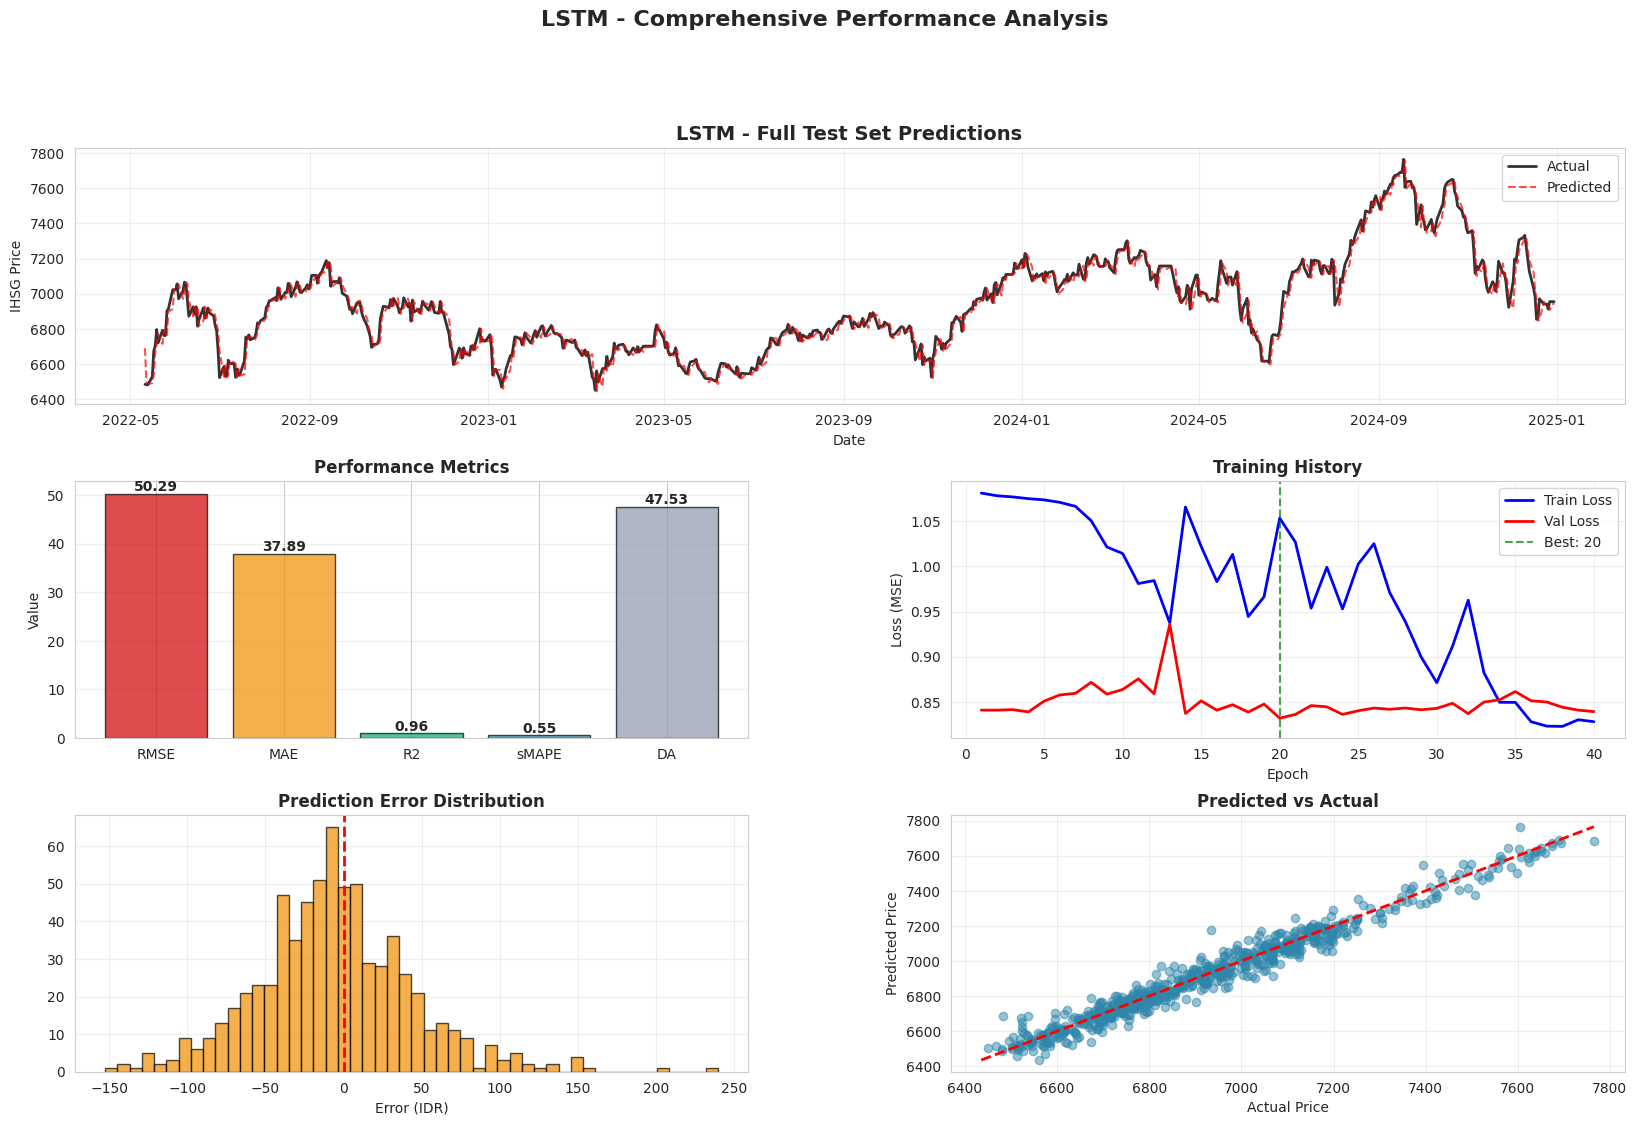

  ✓ Saved: exports-19-oktober-2025/visualizations/lstm_performance.png


In [7]:
# ===================================================================
# SECTION 5: LSTM MODEL
# ===================================================================

print("\n" + "="*70)
print("[SECTION 5] LSTM MODEL")
print("="*70)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, 
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)
    
use_predefined_params = True

if use_predefined_params:
    predefined_params_lstm = {
        'hidden_size': 64, 
        'num_layers': 2, 
        'dropout': 0.12146846558851326, 
        'lr': 0.003801462494535381, 
        'batch_size': 64
    }
    best_params_lstm = predefined_params_lstm
    print("✓ Using predefined LSTM parameters.")
else:
    print("\n[Hyperparameter Tuning - 20 Trials]")

    def objective_lstm(trial):
        params = {
            'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'dropout': trial.suggest_float('dropout', 0.1, 0.3),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        fold_scores = []
        
        for train_idx, val_idx in tscv.split(X_train_seq):
            X_fold_train = X_train_seq[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_seq[val_idx]
            y_fold_val = y_train_seq[val_idx]
            
            train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
            val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))
            
            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=False)
            val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
            
            model = LSTMModel(X_train_scaled.shape[1], params['hidden_size'], 
                            params['num_layers'], params['dropout']).to(config.DEVICE)
            
            criterion = nn.MSELoss()
            optimizer = Adam(model.parameters(), lr=params['lr'])
            
            _, history = train_model(model, train_loader, val_loader, criterion, 
                                    optimizer, epochs=50, patience=10, device=config.DEVICE)
            
            fold_scores.append(min(history['val_loss']))
        
        return np.mean(fold_scores)

    study_lstm = optuna.create_study(direction='minimize')
    study_lstm.optimize(objective_lstm, n_trials=20, show_progress_bar=True)
    best_params_lstm = study_lstm.best_params

print(f"✓ Best params: {best_params_lstm}")

# Final training
val_size = int(len(X_train_seq) * 0.15)
X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]
X_train_final = X_train_seq[:-val_size]
y_train_final = y_train_seq[:-val_size]

train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=best_params_lstm['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_params_lstm['batch_size'], shuffle=False)

lstm_model = LSTMModel(X_train_scaled.shape[1], best_params_lstm['hidden_size'],
                      best_params_lstm['num_layers'], best_params_lstm['dropout']).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(lstm_model.parameters(), lr=best_params_lstm['lr'])

lstm_model, history = train_model(lstm_model, train_loader, val_loader, criterion,
                                 optimizer, epochs=200, patience=20, device=config.DEVICE)

torch.save(lstm_model.state_dict(), f"{config.OUTPUT_DIR}/models/lstm.pt")
trained_models['LSTM'] = lstm_model

# Evaluation
lstm_pred_test, lstm_actual_test = evaluate_model(lstm_model, X_test_seq, y_test_seq,
                                                   scaler_y, config.DEVICE, last_actual_price_train)

metrics = calculate_metrics(lstm_actual_test, lstm_pred_test)
metrics.update(calculate_economic_metrics(lstm_actual_test, lstm_pred_test))
metrics['Model'] = 'LSTM'

all_results.append(metrics)
all_predictions['LSTM'] = {
    'predictions': lstm_pred_test,
    'actuals': lstm_actual_test,
    'dates': test_dates_seq,
    'history': history
}

# Store for ensemble
lstm_model.eval()
with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_seq).to(config.DTYPE).to(config.DEVICE)
    lstm_pred_train_scaled = lstm_model(X_train_tensor).cpu().numpy().flatten()
    
    X_test_tensor = torch.from_numpy(X_test_seq).to(config.DTYPE).to(config.DEVICE)
    lstm_pred_test_scaled = lstm_model(X_test_tensor).cpu().numpy().flatten()

base_model_predictions['LSTM'] = {
    'train_pred_scaled': lstm_pred_train_scaled,
    'test_pred_scaled': lstm_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

plot_individual_model('LSTM', lstm_pred_test, lstm_actual_test, test_dates_seq, 
                     metrics, history, f'{config.OUTPUT_DIR}/visualizations/lstm_performance.png')



[SECTION 6] SIMPLIFIED TCN MODEL
✓ Using predefined TCN parameters.
✓ Best params: {'base_channels': 64, 'num_levels': 3, 'dropout': 0.2832558059711251, 'lr': 0.00401564921756082, 'batch_size': 128}
  Epoch 10/200: Train=0.947931, Val=0.896969
  Epoch 20/200: Train=0.879527, Val=1.223645
  Early stopping at epoch 21

[Metrics]
  RMSE: 54.1791
  MAE: 41.3898
  R2: 0.9589
  sMAPE: 0.5965
  Directional_Accuracy: 47.3837
  Cumulative_Return_%: -30.2717
  Sharpe_Ratio: -2.4439
  Win_Rate_%: 42.5352
  Max_Drawdown_%: -35.1739


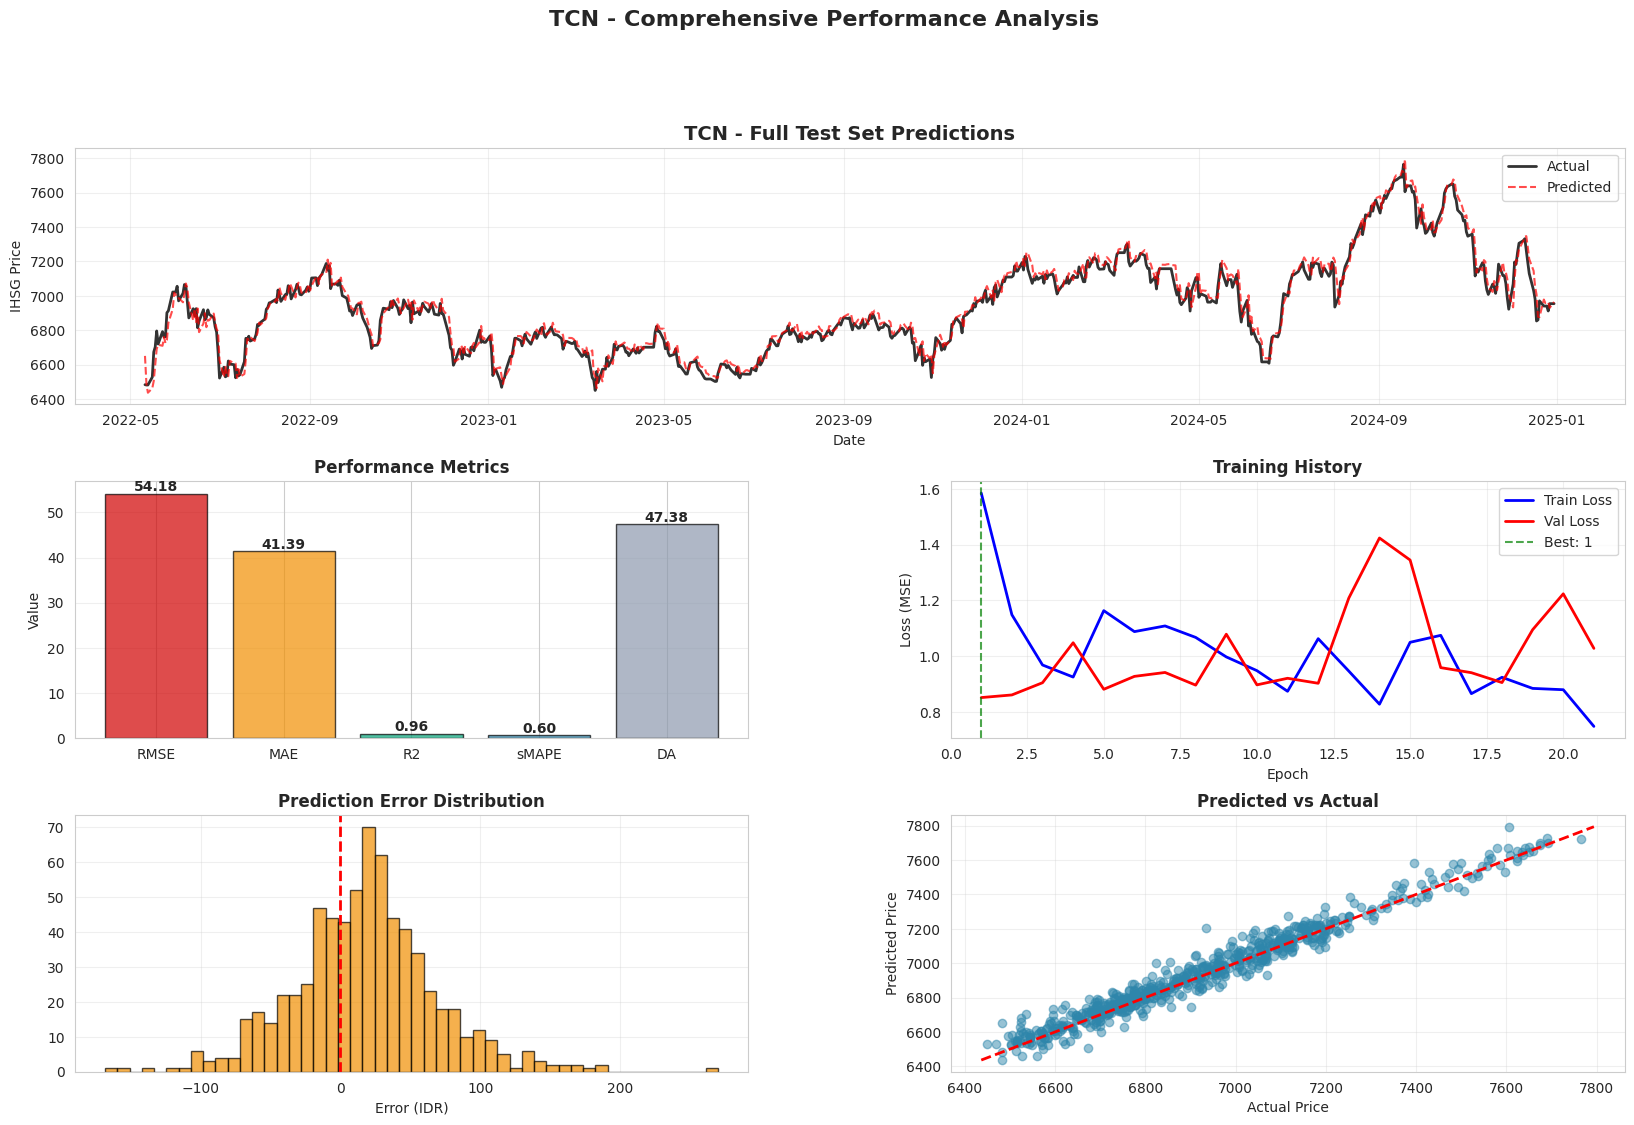

  ✓ Saved: exports-19-oktober-2025/visualizations/tcn_performance.png


In [9]:
# ===================================================================
# SECTION 6: SIMPLIFIED TCN MODEL
# ===================================================================

print("\n" + "="*70)
print("[SECTION 6] SIMPLIFIED TCN MODEL")
print("="*70)

class SimplifiedTCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.chomp_size = padding
    
    def forward(self, x):
        out = self.conv1(x)
        if self.chomp_size > 0:
            out = out[:, :, :-self.chomp_size]
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        res = x if self.downsample is None else self.downsample(x)
        if out.size(2) != res.size(2):
            res = res[:, :, :out.size(2)]
        
        return self.relu(out + res)

class SimplifiedTCN(nn.Module):
    def __init__(self, input_size, num_channels=[64, 128], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            layers.append(SimplifiedTCNBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)
    
    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.network(x)
        out = out[:, :, -1]
        return self.fc(out)

use_predefined_params = True

if use_predefined_params:
    predefined_params_tcn = {
        'base_channels': 64, 
        'num_levels': 3, 
        'dropout': 0.2832558059711251, 
        'lr': 0.00401564921756082, 
        'batch_size': 128
    }
    best_params_tcn = predefined_params_tcn
    print("✓ Using predefined TCN parameters.")
else:
    print("\n[Hyperparameter Tuning - 20 Trials]")

    def objective_tcn(trial):
        base_channels = trial.suggest_categorical('base_channels', [32, 64])
        num_levels = trial.suggest_int('num_levels', 2, 3)
        
        params = {
            'num_channels': [base_channels * (i+1) for i in range(num_levels)],
            'kernel_size': 3,
            'dropout': trial.suggest_float('dropout', 0.1, 0.3),
            'lr': trial.suggest_float('lr', 5e-4, 5e-3, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256])
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        fold_scores = []
        
        for train_idx, val_idx in tscv.split(X_train_seq):
            X_fold_train = X_train_seq[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_seq[val_idx]
            y_fold_val = y_train_seq[val_idx]
            
            train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
            val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))
            
            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], 
                                    shuffle=False, num_workers=config.NUM_THREADS)
            val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], 
                                shuffle=False, num_workers=config.NUM_THREADS)
            
            model = SimplifiedTCN(X_train_scaled.shape[1], params['num_channels'],
                                params['kernel_size'], params['dropout']).to(config.DEVICE)
            
            criterion = nn.MSELoss()
            optimizer = Adam(model.parameters(), lr=params['lr'])
            
            _, history = train_model(model, train_loader, val_loader, criterion,
                                    optimizer, epochs=30, patience=8, device=config.DEVICE)
            
            fold_scores.append(min(history['val_loss']))
        
        return np.mean(fold_scores)

    study_tcn = optuna.create_study(direction='minimize')
    study_tcn.optimize(objective_tcn, n_trials=20, show_progress_bar=True)
    best_params_tcn = study_tcn.best_params


print(f"✓ Best params: {best_params_tcn}")

num_levels = best_params_tcn['num_levels']
base_channels = best_params_tcn['base_channels']
best_params_tcn['num_channels'] = [base_channels * (i+1) for i in range(num_levels)]
best_params_tcn['kernel_size'] = 3
# Final training
train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=best_params_tcn['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_params_tcn['batch_size'], shuffle=False)

tcn_model = SimplifiedTCN(X_train_scaled.shape[1], best_params_tcn['num_channels'],
                         best_params_tcn['kernel_size'], best_params_tcn['dropout']).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(tcn_model.parameters(), lr=best_params_tcn['lr'])

tcn_model, history = train_model(tcn_model, train_loader, val_loader, criterion,
                                optimizer, epochs=200, patience=20, device=config.DEVICE)

torch.save(tcn_model.state_dict(), f"{config.OUTPUT_DIR}/models/tcn.pt")
trained_models['TCN'] = tcn_model

# Evaluation
tcn_pred_test, tcn_actual_test = evaluate_model(tcn_model, X_test_seq, y_test_seq,
                                                scaler_y, config.DEVICE, last_actual_price_train)

metrics = calculate_metrics(tcn_actual_test, tcn_pred_test)
metrics.update(calculate_economic_metrics(tcn_actual_test, tcn_pred_test))
metrics['Model'] = 'TCN'

all_results.append(metrics)
all_predictions['TCN'] = {
    'predictions': tcn_pred_test,
    'actuals': tcn_actual_test,
    'dates': test_dates_seq,
    'history': history
}

# Store for ensemble
tcn_model.eval()
with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_seq).to(config.DTYPE).to(config.DEVICE)
    tcn_pred_train_scaled = tcn_model(X_train_tensor).cpu().numpy().flatten()
    
    X_test_tensor = torch.from_numpy(X_test_seq).to(config.DTYPE).to(config.DEVICE)
    tcn_pred_test_scaled = tcn_model(X_test_tensor).cpu().numpy().flatten()

base_model_predictions['TCN'] = {
    'train_pred_scaled': tcn_pred_train_scaled,
    'test_pred_scaled': tcn_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

plot_individual_model('TCN', tcn_pred_test, tcn_actual_test, test_dates_seq,
                     metrics, history, f'{config.OUTPUT_DIR}/visualizations/tcn_performance.png')


In [ ]:
# ===================================================================
# SECTION 7: TABNET STANDALONE MODEL (FIXED)
# ===================================================================

print("\n" + "="*70)
print("[SECTION 7] TABNET STANDALONE MODEL")
print("="*70)

def extract_temporal_features(X_seq):
    """Extract more meaningful statistical features"""
    features_list = [
        X_seq[:, -1, :],                          # Last timestep (t)
        X_seq[:, -2, :] if X_seq.shape[1] >= 2 else X_seq[:, -1, :],  # t-1
        X_seq[:, -5, :] if X_seq.shape[1] >= 5 else X_seq[:, -1, :],  # t-5
        np.mean(X_seq, axis=1),                   # Mean
        np.std(X_seq, axis=1),                    # Std
        np.min(X_seq, axis=1),                    # Min
        np.max(X_seq, axis=1),                    # Max
        X_seq[:, -1, :] - X_seq[:, 0, :],        # Change (last - first)
        np.percentile(X_seq, 25, axis=1),         # Q1
        np.percentile(X_seq, 75, axis=1),         # Q3
        np.median(X_seq, axis=1),                 # Median
        # Trend features
        np.array([np.polyfit(range(X_seq.shape[1]), X_seq[i, :, j], 1)[0] 
                  for i in range(X_seq.shape[0]) 
                  for j in range(X_seq.shape[2])]).reshape(X_seq.shape[0], X_seq.shape[2]),
    ]
    return np.concatenate(features_list, axis=1)

print("\n[Extracting temporal features from sequences]")
X_train_flat = extract_temporal_features(X_train_seq)
X_test_flat = extract_temporal_features(X_test_seq)

print(f"  Sequence shape: {X_train_seq.shape}")
print(f"  Extracted shape: {X_train_flat.shape}")

# Categorical features
categorical_idxs = []
categorical_dims = []
for feat_name in ['DayOfWeek', 'Month', 'Quarter']:
    if feat_name in feature_cols:
        idx = feature_cols.index(feat_name)
        categorical_idxs.append(idx)
        if feat_name == 'DayOfWeek':
            categorical_dims.append(7)
        elif feat_name == 'Month':
            categorical_dims.append(12)
        elif feat_name == 'Quarter':
            categorical_dims.append(4)

print(f"  Categorical features: {len(categorical_idxs)}")

# Split validation
val_size = int(len(X_train_flat) * 0.15)
X_train_tabnet = X_train_flat[:-val_size]
X_val_tabnet = X_train_flat[-val_size:]
y_train_tabnet = y_train_seq[:-val_size]
y_val_tabnet = y_train_seq[-val_size:]

# best params = {
#     'batch_size': 512,
#      'n_d': 64, 'n_a': 64,
#      'n_steps': 8, 'gamma': 1.0514945702018803,
#      'lambda_sparse': 1.777830652544828e-06, 'mask_type': 'sparsemax',
#      'lr': 0.0156645728697659, 'cat_emb_dim': 1
#}


print("\n[Hyperparameter Tuning - 20 Trials]")

def objective_tabnet(trial):
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256, 512])
    virtual_batch_size = batch_size // 4
    
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_categorical('n_steps', [4, 5, 6, 7, 8]),
        'gamma': trial.suggest_float('gamma', 1.0, 2.5),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-2, log=True),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax']),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-3, 3e-2, log=True)),
        'scheduler_params': {"step_size": 30, "gamma": 0.95},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'seed': config.SEED,
        'verbose': 0
    }
    
    if len(categorical_idxs) > 0:
        params['cat_idxs'] = categorical_idxs
        params['cat_dims'] = categorical_dims
        params['cat_emb_dim'] = trial.suggest_int("cat_emb_dim", 1, 3)
    
    tscv = TimeSeriesSplit(n_splits=2)
    fold_scores = []
    
    for train_idx, val_idx in tscv.split(X_train_flat):
        X_fold_train = X_train_flat[train_idx]
        y_fold_train = y_train_seq[train_idx]
        X_fold_val = X_train_flat[val_idx]
        y_fold_val = y_train_seq[val_idx]
        
        model = TabNetRegressor(**params)
        
        model.fit(
            X_fold_train, y_fold_train.reshape(-1, 1),
            eval_set=[(X_fold_val, y_fold_val.reshape(-1, 1))],
            max_epochs=150,
            patience=20,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            eval_metric=['rmse']
        )
        
        val_pred = model.predict(X_fold_val)
        val_score = mean_squared_error(y_fold_val.reshape(-1, 1), val_pred)
        fold_scores.append(val_score)
    
    return np.mean(fold_scores)

study_tabnet = optuna.create_study(direction='minimize')
study_tabnet.optimize(objective_tabnet, n_trials=50, show_progress_bar=True)

best_params_tabnet = study_tabnet.best_params
batch_size = best_params_tabnet['batch_size']
virtual_batch_size = batch_size // 4

final_params = {
    'n_d': best_params_tabnet['n_d'],
    'n_a': best_params_tabnet['n_a'],
    'n_steps': best_params_tabnet['n_steps'],
    'gamma': best_params_tabnet['gamma'],
    'lambda_sparse': best_params_tabnet['lambda_sparse'],
    'mask_type': best_params_tabnet['mask_type'],
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=best_params_tabnet['lr']),
    'scheduler_params': {"step_size": 50, "gamma": 0.9},
    'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    'seed': config.SEED,
    'verbose': 1
}

if len(categorical_idxs) > 0:
    final_params['cat_idxs'] = categorical_idxs
    final_params['cat_dims'] = categorical_dims
    final_params['cat_emb_dim'] = best_params_tabnet['cat_emb_dim']

print(f"✓ Best params: {best_params_tabnet}")

# Final training
print("\n[Training TabNet]")
tabnet_model = TabNetRegressor(**final_params)

tabnet_model.fit(
    X_train_tabnet, y_train_tabnet.reshape(-1, 1),
    eval_set=[(X_val_tabnet, y_val_tabnet.reshape(-1, 1))],
    max_epochs=300,
    patience=30,
    batch_size=batch_size,
    virtual_batch_size=virtual_batch_size,
    eval_metric=['rmse']
)

# Get predictions in SCALED space (returns)
tabnet_pred_test_scaled = tabnet_model.predict(X_test_flat).flatten()
tabnet_pred_train_scaled = tabnet_model.predict(X_train_flat).flatten()

# Inverse transform to get actual returns
tabnet_pred_returns = scaler_y.inverse_transform(tabnet_pred_test_scaled.reshape(-1, 1)).flatten()
tabnet_actual_returns = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Reconstruct prices from returns
base_prices = [last_actual_price_train]
for ret in tabnet_actual_returns:
    base_prices.append(base_prices[-1] * (1 + ret))

tabnet_pred_test = np.zeros_like(tabnet_pred_returns)
tabnet_actual_test = np.zeros_like(tabnet_actual_returns)

for i in range(len(tabnet_pred_returns)):
    tabnet_pred_test[i] = base_prices[i] * (1 + tabnet_pred_returns[i])
    tabnet_actual_test[i] = base_prices[i] * (1 + tabnet_actual_returns[i])

joblib.dump(tabnet_model, f"{config.OUTPUT_DIR}/models/tabnet.pkl")
trained_models['TabNet'] = tabnet_model

# Evaluation
metrics = calculate_metrics(tabnet_actual_test, tabnet_pred_test)
metrics.update(calculate_economic_metrics(tabnet_actual_test, tabnet_pred_test))
metrics['Model'] = 'TabNet'

all_results.append(metrics)
all_predictions['TabNet'] = {
    'predictions': tabnet_pred_test,
    'actuals': tabnet_actual_test,
    'dates': test_dates_seq,
    'history': None
}

# Store for ensemble
base_model_predictions['TabNet'] = {
    'train_pred_scaled': tabnet_pred_train_scaled,
    'test_pred_scaled': tabnet_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Custom plot for TabNet (no training history)
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, tabnet_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, tabnet_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title('TabNet - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
metric_values = [metrics['RMSE'], metrics['MAE'], metrics['R2'], 
                 metrics['sMAPE'], metrics['Directional_Accuracy']]
colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
ax3.text(0.5, 0.5, 'No epoch-based training\n(TabNet uses early stopping)', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Training History', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = tabnet_pred_test - tabnet_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(tabnet_actual_test, tabnet_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(tabnet_actual_test.min(), tabnet_pred_test.min()), max(tabnet_actual_test.max(), tabnet_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle('TabNet - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/tabnet_performance.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"  ✓ Saved: {config.OUTPUT_DIR}/visualizations/tabnet_performance.png")



[SECTION 7] TABNET STANDALONE MODEL

[Extracting temporal features from sequences]


[I 2025-10-19 12:22:14,478] A new study created in memory with name: no-name-eaa4b49b-db79-443b-9ee4-5eb11e072092


  Sequence shape: (3024, 90, 51)
  Extracted shape: (3024, 612)
  Categorical features: 3

[Hyperparameter Tuning - 20 Trials]


  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping occurred at epoch 23 with best_epoch = 3 and best_val_0_mae = 0.53089

Early stopping occurred at epoch 53 with best_epoch = 33 and best_val_0_mae = 0.69237


...

[I 2025-10-19 15:09:36,646] Trial 47 finished with value: 0.8368218541145325 and parameters: {'batch_size': 256, 'n_d': 128, 'n_a': 32, 'n_steps': 6, 'gamma': 1.176029087773592, 'lambda_sparse': 5.656067012638039e-05, 'mask_type': 'sparsemax', 'lr': 0.005105137698438441, 'cat_emb_dim': 2}. Best is trial 5 with value: 0.826059103012085.

Early stopping occurred at epoch 55 with best_epoch = 35 and best_val_0_mae = 0.52579

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_mae = 0.69289


Best trial: 5. Best value: 0.826059:  98%|█████████▊| 49/50 [2:52:30<03:51, 231.95s/it]

[I 2025-10-19 15:14:45,297] Trial 48 finished with value: 0.831340104341507 and parameters: {'batch_size': 64, 'n_d': 32, 'n_a': 64, 'n_steps': 5, 'gamma': 1.4594516506429693, 'lambda_sparse': 2.1656394837581257e-06, 'mask_type': 'sparsemax', 'lr': 0.02270706882980758, 'cat_emb_dim': 1}. Best is trial 5 with value: 0.826059103012085.

Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_0_mae = 0.52615

Early stopping occurred at epoch 69 with best_epoch = 49 and best_val_0_mae = 0.69433


Best trial: 5. Best value: 0.826059: 100%|██████████| 50/50 [3:03:14<00:00, 219.89s/it]


[I 2025-10-19 15:25:29,064] Trial 49 finished with value: 0.8286435008049011 and parameters: {'batch_size': 128, 'n_d': 64, 'n_a': 256, 'n_steps': 8, 'gamma': 1.825884374796222, 'lambda_sparse': 4.0731918763270276e-06, 'mask_type': 'sparsemax', 'lr': 0.013021438541191319, 'cat_emb_dim': 2}. Best is trial 5 with value: 0.826059103012085.
✓ Best params: {'batch_size': 512, 'n_d': 64, 'n_a': 64, 'n_steps': 8, 'gamma': 1.0514945702018803, 'lambda_sparse': 1.777830652544828e-06, 'mask_type': 'sparsemax', 'lr': 0.0156645728697659, 'cat_emb_dim': 1}

[Training TabNet]
epoch 0  | loss: 11.13342| val_0_rmse: 0.96094 | val_0_mae: 0.70182 |  0:00:02s
epoch 1  | loss: 6.53055 | val_0_rmse: 0.94458 | val_0_mae: 0.6815  |  0:00:04s
epoch 2  | loss: 4.77446 | val_0_rmse: 0.94573 | val_0_mae: 0.68914 |  0:00:07s
epoch 3  | loss: 3.83024 | val_0_rmse: 0.95052 | val_0_mae: 0.68516 |  0:00:09s
epoch 4  | loss: 3.37997 | val_0_rmse: 0.95349 | val_0_mae: 0.68729 |  0:00:11s
epoch 5  | loss: 2.83715 | val_0

[I 2025-10-19 15:28:11,091] A new study created in memory with name: no-name-e705c9c9-a0df-4846-99ca-5f116b672ff7



[SECTION 8] TABNET-LSTM HYBRID MODEL

[Hyperparameter Tuning - 20 Trials]


  0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 10/50: Train=0.857770, Val=1.270728
  Early stopping at epoch 11
  Epoch 10/50: Train=0.806009, Val=3.033630
  Early stopping at epoch 11
  Epoch 10/50: Train=0.661341, Val=1.472806


Best trial: 0. Best value: 1.0124:   2%|▏         | 1/50 [02:43<2:13:14, 163.15s/it]

...

Best trial: 39. Best value: 0.91876:  98%|█████████▊| 49/50 [2:50:12<03:06, 186.69s/it]

  Early stopping at epoch 11
[I 2025-10-19 18:18:23,503] Trial 48 finished with value: 0.9820431417061223 and parameters: {'n_d': 64, 'n_a': 32, 'n_steps': 4, 'lstm_hidden': 128, 'lstm_layers': 2, 'dropout': 0.14447339373888402, 'lr': 0.00043682952613483325, 'batch_size': 32}. Best is trial 39 with value: 0.918760162881679.
  Epoch 10/50: Train=0.778703, Val=1.225590
  Early stopping at epoch 11
  Epoch 10/50: Train=0.727838, Val=1.737018
  Early stopping at epoch 11
  Epoch 10/50: Train=0.587151, Val=1.300386


Best trial: 39. Best value: 0.91876: 100%|██████████| 50/50 [2:52:10<00:00, 206.60s/it]

  Early stopping at epoch 11
[I 2025-10-19 18:20:21,310] Trial 49 finished with value: 0.9308007094595169 and parameters: {'n_d': 128, 'n_a': 32, 'n_steps': 3, 'lstm_hidden': 64, 'lstm_layers': 3, 'dropout': 0.21056955608409306, 'lr': 0.0017109698198441096, 'batch_size': 128}. Best is trial 39 with value: 0.918760162881679.
✓ Best params: {'n_d': 64, 'n_a': 32, 'n_steps': 3, 'lstm_hidden': 64, 'lstm_layers': 3, 'dropout': 0.16962676277003047, 'lr': 0.00013192646440317416, 'batch_size': 32}


  Epoch 10/200: Train=0.936392, Val=0.886918
  Epoch 20/200: Train=0.755700, Val=1.275094
  Early stopping at epoch 21

[Metrics]
  RMSE: 55.5817
  MAE: 42.0252
  R2: 0.9567
  sMAPE: 0.6055
  Directional_Accuracy: 46.6570
  Cumulative_Return_%: -31.2015
  Sharpe_Ratio: -2.4584
  Win_Rate_%: 42.3398
  Max_Drawdown_%: -36.7407


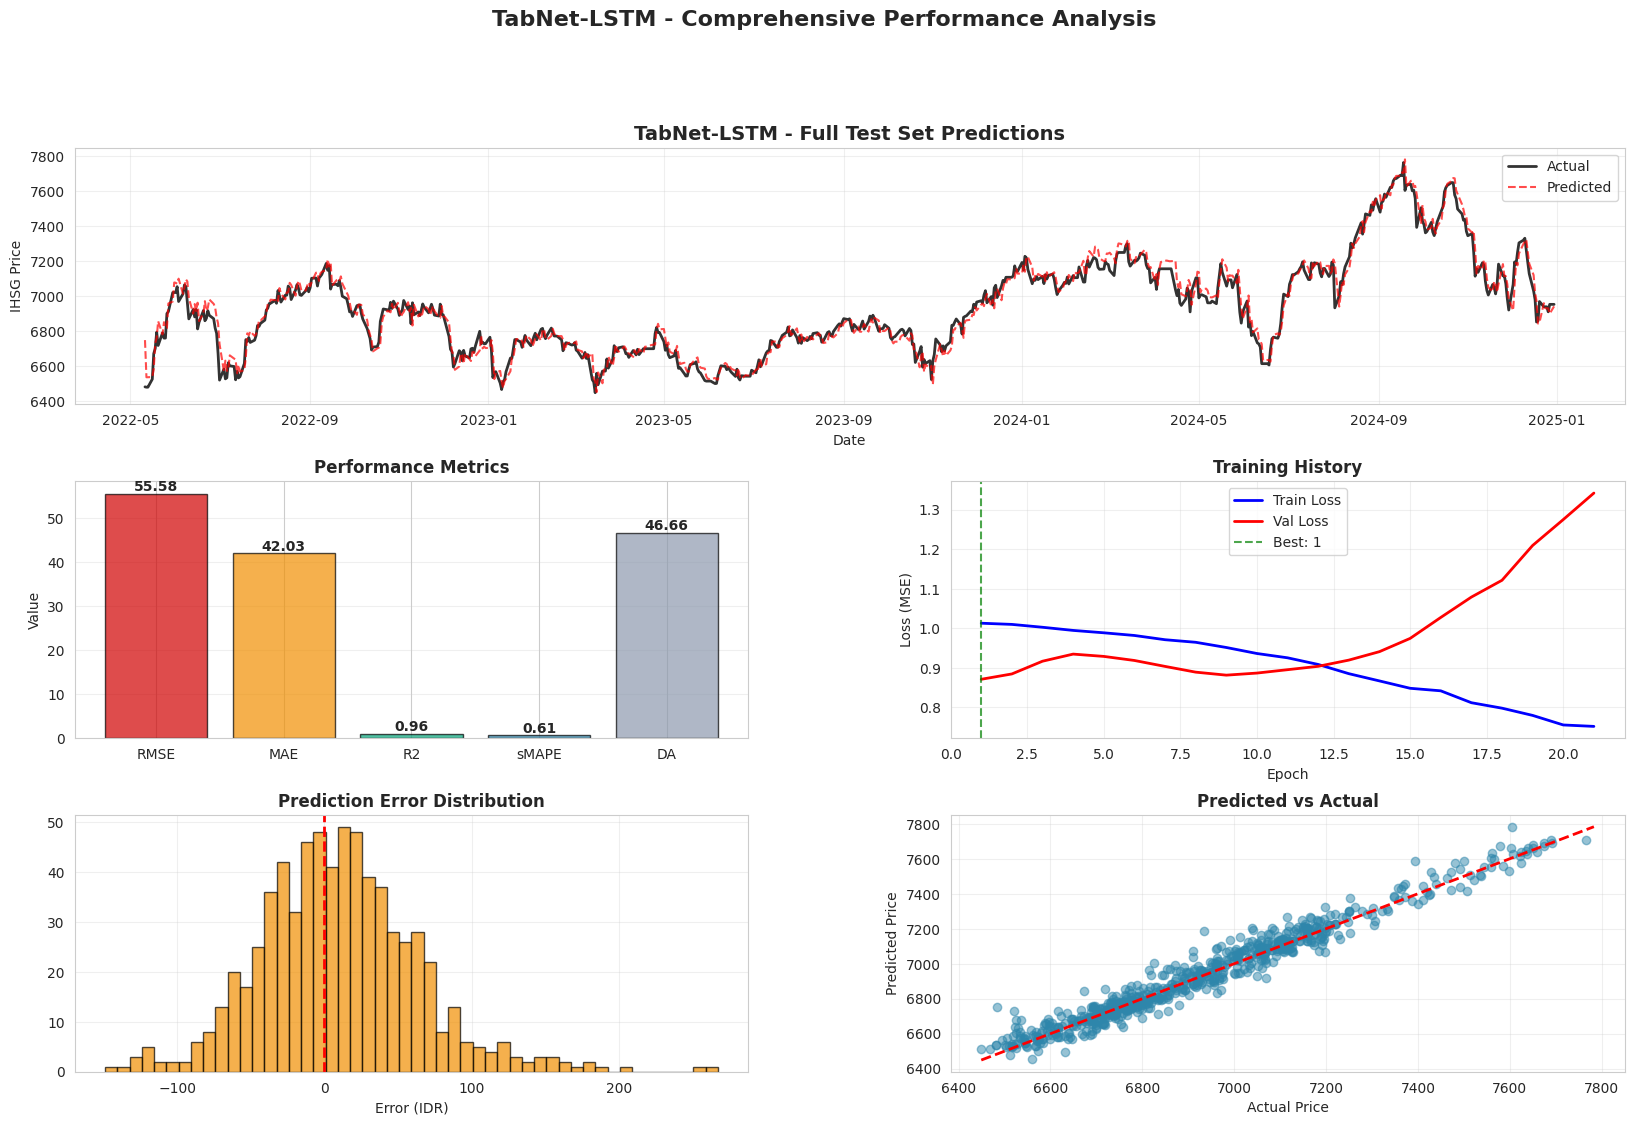

  ✓ Saved: exports-19-oktober-2025/visualizations/tabnet_lstm_performance.png


In [11]:
# ===================================================================
# SECTION 8: TABNET-LSTM HYBRID MODEL
# ===================================================================

print("\n" + "="*70)
print("[SECTION 8] TABNET-LSTM HYBRID MODEL")
print("="*70)

class TabNetLSTM(nn.Module):
    def __init__(self, input_size, tabnet_params, lstm_hidden, lstm_layers, dropout=0.2):
        super().__init__()
        
        tabnet_output_size = tabnet_params['n_d'] + tabnet_params['n_a']
        
        self.initial_bn = nn.BatchNorm1d(input_size)
        
        self.feature_transformer = nn.Sequential(
            nn.Linear(input_size, tabnet_output_size * 2),
            nn.BatchNorm1d(tabnet_output_size * 2),
            nn.GLU(dim=1),
        )
        
        self.attention_weights = nn.Linear(tabnet_output_size, input_size)
        
        self.lstm = nn.LSTM(tabnet_output_size, lstm_hidden, lstm_layers,
                           batch_first=True, dropout=dropout if lstm_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)
        
        self.last_attention_mask = None
    
    def forward(self, x):
        batch_size, seq_len, n_features = x.shape
        
        tabnet_embeddings = []
        
        for t in range(seq_len):
            x_t = x[:, t, :]
            x_t_norm = self.initial_bn(x_t)
            embedding = self.feature_transformer(x_t_norm)
            
            if t == seq_len - 1:
                attention_logits = self.attention_weights(embedding)
                self.last_attention_mask = torch.softmax(attention_logits, dim=1)
            
            tabnet_embeddings.append(embedding)
        
        tabnet_sequence = torch.stack(tabnet_embeddings, dim=1)
        
        lstm_out, _ = self.lstm(tabnet_sequence)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        
        return self.fc(out)
    
    def get_mask(self):
        return self.last_attention_mask

print("\n[Hyperparameter Tuning - 20 Trials]")

def objective_tabnet_lstm(trial):
    tabnet_params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 7)
    }
    
    params = {
        'tabnet_params': tabnet_params,
        'lstm_hidden': trial.suggest_categorical('lstm_hidden', [64, 128, 256]),
        'lstm_layers': trial.suggest_int('lstm_layers', 1, 3),
        'dropout': trial.suggest_float('dropout', 0.1, 0.3),
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    fold_scores = []
    
    for train_idx, val_idx in tscv.split(X_train_seq):
        X_fold_train = X_train_seq[train_idx]
        y_fold_train = y_train_seq[train_idx]
        X_fold_val = X_train_seq[val_idx]
        y_fold_val = y_train_seq[val_idx]
        
        train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
        val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))
        
        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
        
        model = TabNetLSTM(X_train_scaled.shape[1], tabnet_params, 
                          params['lstm_hidden'], params['lstm_layers'], 
                          params['dropout']).to(config.DEVICE)
        
        criterion = nn.MSELoss()
        optimizer = Adam(model.parameters(), lr=params['lr'])
        
        _, history = train_model(model, train_loader, val_loader, criterion,
                                optimizer, epochs=50, patience=10, device=config.DEVICE)
        
        fold_scores.append(min(history['val_loss']))
    
    return np.mean(fold_scores)

study_tabnet_lstm = optuna.create_study(direction='minimize')
study_tabnet_lstm.optimize(objective_tabnet_lstm, n_trials=50, show_progress_bar=True)

best_params_hybrid = study_tabnet_lstm.best_params
tabnet_params = {
    'n_d': best_params_hybrid['n_d'],
    'n_a': best_params_hybrid['n_a'],
    'n_steps': best_params_hybrid['n_steps']
}

print(f"✓ Best params: {best_params_hybrid}")

# Final training
train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=best_params_hybrid['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_params_hybrid['batch_size'], shuffle=False)

tabnet_lstm_model = TabNetLSTM(
    X_train_scaled.shape[1], tabnet_params, 
    best_params_hybrid['lstm_hidden'], best_params_hybrid['lstm_layers'],
    best_params_hybrid['dropout']
).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(tabnet_lstm_model.parameters(), lr=best_params_hybrid['lr'])

tabnet_lstm_model, history = train_model(tabnet_lstm_model, train_loader, val_loader, 
                                         criterion, optimizer, epochs=200, patience=20, 
                                         device=config.DEVICE)

torch.save(tabnet_lstm_model.state_dict(), f"{config.OUTPUT_DIR}/models/tabnet_lstm.pt")
trained_models['TabNet-LSTM'] = tabnet_lstm_model

# Evaluation
tabnet_lstm_pred_test, tabnet_lstm_actual_test = evaluate_model(
    tabnet_lstm_model, X_test_seq, y_test_seq, scaler_y, config.DEVICE, last_actual_price_train
)

metrics = calculate_metrics(tabnet_lstm_actual_test, tabnet_lstm_pred_test)
metrics.update(calculate_economic_metrics(tabnet_lstm_actual_test, tabnet_lstm_pred_test))
metrics['Model'] = 'TabNet-LSTM'

all_results.append(metrics)
all_predictions['TabNet-LSTM'] = {
    'predictions': tabnet_lstm_pred_test,
    'actuals': tabnet_lstm_actual_test,
    'dates': test_dates_seq,
    'history': history
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

plot_individual_model('TabNet-LSTM', tabnet_lstm_pred_test, tabnet_lstm_actual_test, 
                     test_dates_seq, metrics, history, 
                     f'{config.OUTPUT_DIR}/visualizations/tabnet_lstm_performance.png')


In [12]:
# ===================================================================
# SECTION 9: RANDOMFOREST BENCHMARK
# ===================================================================

print("\n" + "="*70)
print("[SECTION 9] RANDOMFOREST BENCHMARK")
print("="*70)

X_train_flat_rf = X_train_seq.reshape(len(X_train_seq), -1)
X_test_flat_rf = X_test_seq.reshape(len(X_test_seq), -1)

rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=5,
                                 min_samples_leaf=2, random_state=config.SEED, n_jobs=-1)

print("[Training RandomForest]")
rf_model.fit(X_train_flat_rf, y_train_seq)

rf_pred_scaled = rf_model.predict(X_test_flat_rf)
rf_pred_returns = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1)).flatten()
rf_actual_returns = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Reconstruct prices
base_prices = [last_actual_price_train]
for ret in rf_actual_returns:
    base_prices.append(base_prices[-1] * (1 + ret))

rf_pred_test = np.zeros_like(rf_pred_returns)
rf_actual_test = np.zeros_like(rf_actual_returns)

for i in range(len(rf_pred_returns)):
    rf_pred_test[i] = base_prices[i] * (1 + rf_pred_returns[i])
    rf_actual_test[i] = base_prices[i] * (1 + rf_actual_returns[i])

joblib.dump(rf_model, f"{config.OUTPUT_DIR}/models/randomforest.pkl")
trained_models['RandomForest'] = rf_model

metrics = calculate_metrics(rf_actual_test, rf_pred_test)
metrics.update(calculate_economic_metrics(rf_actual_test, rf_pred_test))
metrics['Model'] = 'RandomForest'

all_results.append(metrics)
all_predictions['RandomForest'] = {
    'predictions': rf_pred_test,
    'actuals': rf_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Custom plot for RF
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, rf_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, rf_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title('RandomForest - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
metric_values = [metrics['RMSE'], metrics['MAE'], metrics['R2'], 
                 metrics['sMAPE'], metrics['Directional_Accuracy']]
colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
ax3.text(0.5, 0.5, 'No epoch-based training\n(RandomForest uses ensemble)', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Training History', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = rf_pred_test - rf_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(rf_actual_test, rf_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(rf_actual_test.min(), rf_pred_test.min()), max(rf_actual_test.max(), rf_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle('RandomForest - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/randomforest_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: {config.OUTPUT_DIR}/visualizations/randomforest_performance.png")


[SECTION 9] RANDOMFOREST BENCHMARK
[Training RandomForest]

[Metrics]
  RMSE: 51.6935
  MAE: 38.6753
  R2: 0.9626
  sMAPE: 0.5576
  Directional_Accuracy: 47.9651
  Cumulative_Return_%: -30.8155
  Sharpe_Ratio: -2.3984
  Win_Rate_%: 42.9708
  Max_Drawdown_%: -36.5363
  ✓ Saved: exports-19-oktober-2025/visualizations/randomforest_performance.png


In [13]:
# ===================================================================
# SECTION 10: META-LEARNER ENSEMBLE (2 VARIANTS)
# ===================================================================

print("\n" + "="*70)
print("[SECTION 10] META-LEARNER ENSEMBLE")
print("="*70)

def train_meta_learner_with_tuning(X_meta_train, y_train, X_meta_val, y_val, model_type='ElasticNet'):
    """Train meta-learner with Optuna tuning"""
    
    def objective(trial):
        if model_type == 'ElasticNet':
            alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
            l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=config.SEED, max_iter=5000)
        else:  # Ridge
            alpha = trial.suggest_float('alpha', 0.001, 1000.0, log=True)
            model = Ridge(alpha=alpha, random_state=config.SEED)
        
        model.fit(X_meta_train, y_train)
        val_pred = model.predict(X_meta_val)
        val_score = mean_squared_error(y_val, val_pred)
        
        return val_score
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    
    best_params = study.best_params
    
    if model_type == 'ElasticNet':
        best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'],
                               random_state=config.SEED, max_iter=5000)
    else:
        best_model = Ridge(alpha=best_params['alpha'], random_state=config.SEED)
    
    best_model.fit(X_meta_train, y_train)
    
    return best_model, best_params, study.best_value

# Variant 1: TabNet + LSTM
print("\n[VARIANT 1: TabNet + LSTM Ensemble]")

X_meta_train_v1 = np.column_stack([
    base_model_predictions['TabNet']['train_pred_scaled'],
    base_model_predictions['LSTM']['train_pred_scaled']
])

X_meta_test_v1 = np.column_stack([
    base_model_predictions['TabNet']['test_pred_scaled'],
    base_model_predictions['LSTM']['test_pred_scaled']
])

# Add interaction features
avg_train = np.mean(X_meta_train_v1, axis=1, keepdims=True)
diff_train = (X_meta_train_v1[:, 0] - X_meta_train_v1[:, 1]).reshape(-1, 1)
interaction_train = (X_meta_train_v1[:, 0] * X_meta_train_v1[:, 1]).reshape(-1, 1)
X_meta_train_v1 = np.concatenate([X_meta_train_v1, avg_train, diff_train, interaction_train, np.abs(diff_train)], axis=1)

avg_test = np.mean(X_meta_test_v1, axis=1, keepdims=True)
diff_test = (X_meta_test_v1[:, 0] - X_meta_test_v1[:, 1]).reshape(-1, 1)
interaction_test = (X_meta_test_v1[:, 0] * X_meta_test_v1[:, 1]).reshape(-1, 1)
X_meta_test_v1 = np.concatenate([X_meta_test_v1, avg_test, diff_test, interaction_test, np.abs(diff_test)], axis=1)

y_meta_train = base_model_predictions['TabNet']['train_actual_scaled']
y_meta_test = base_model_predictions['TabNet']['test_actual_scaled']

val_size_meta = int(len(X_meta_train_v1) * 0.15)
X_meta_train_v1_final = X_meta_train_v1[:-val_size_meta]
X_meta_val_v1 = X_meta_train_v1[-val_size_meta:]
y_meta_train_final = y_meta_train[:-val_size_meta]
y_meta_val = y_meta_train[-val_size_meta:]

print("\n  Training ElasticNet meta-learner (20 trials)")
elasticnet_v1, elasticnet_params_v1, elasticnet_score_v1 = train_meta_learner_with_tuning(
    X_meta_train_v1_final, y_meta_train_final, X_meta_val_v1, y_meta_val, 'ElasticNet'
)

print("\n  Training Ridge meta-learner (20 trials)")
ridge_v1, ridge_params_v1, ridge_score_v1 = train_meta_learner_with_tuning(
    X_meta_train_v1_final, y_meta_train_final, X_meta_val_v1, y_meta_val, 'Ridge'
)

print(f"\n  ElasticNet Val MSE: {elasticnet_score_v1:.6f} | Params: {elasticnet_params_v1}")
print(f"  Ridge Val MSE: {ridge_score_v1:.6f} | Params: {ridge_params_v1}")

if elasticnet_score_v1 < ridge_score_v1:
    best_meta_v1 = elasticnet_v1
    best_meta_name_v1 = 'ElasticNet'
    print(f"  ✓ Selected: ElasticNet")
else:
    best_meta_v1 = ridge_v1
    best_meta_name_v1 = 'Ridge'
    print(f"  ✓ Selected: Ridge")

# Predictions
ensemble_v1_pred_scaled = best_meta_v1.predict(X_meta_test_v1)
ensemble_v1_pred_returns = scaler_y.inverse_transform(ensemble_v1_pred_scaled.reshape(-1, 1)).flatten()
ensemble_v1_actual_returns = scaler_y.inverse_transform(y_meta_test.reshape(-1, 1)).flatten()

# Reconstruct prices
base_prices = [last_actual_price_train]
for ret in ensemble_v1_actual_returns:
    base_prices.append(base_prices[-1] * (1 + ret))

ensemble_v1_pred_test = np.zeros_like(ensemble_v1_pred_returns)
ensemble_v1_actual_test = np.zeros_like(ensemble_v1_actual_returns)

for i in range(len(ensemble_v1_pred_returns)):
    ensemble_v1_pred_test[i] = base_prices[i] * (1 + ensemble_v1_pred_returns[i])
    ensemble_v1_actual_test[i] = base_prices[i] * (1 + ensemble_v1_actual_returns[i])

joblib.dump(best_meta_v1, f"{config.OUTPUT_DIR}/models/ensemble_v1_{best_meta_name_v1}.pkl")

metrics = calculate_metrics(ensemble_v1_actual_test, ensemble_v1_pred_test)
metrics.update(calculate_economic_metrics(ensemble_v1_actual_test, ensemble_v1_pred_test))
metrics['Model'] = f'Ensemble-V1-{best_meta_name_v1}'

all_results.append(metrics)
all_predictions[f'Ensemble-V1-{best_meta_name_v1}'] = {
    'predictions': ensemble_v1_pred_test,
    'actuals': ensemble_v1_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Variant 1 Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Variant 2: TabNet + LSTM + TCN
print("\n[VARIANT 2: TabNet + LSTM + TCN Ensemble]")

X_meta_train_v2 = np.column_stack([
    base_model_predictions['TabNet']['train_pred_scaled'],
    base_model_predictions['LSTM']['train_pred_scaled'],
    base_model_predictions['TCN']['train_pred_scaled']
])

X_meta_test_v2 = np.column_stack([
    base_model_predictions['TabNet']['test_pred_scaled'],
    base_model_predictions['LSTM']['test_pred_scaled'],
    base_model_predictions['TCN']['test_pred_scaled']
])

# Add avg feature
avg_train_v2 = np.mean(X_meta_train_v2, axis=1, keepdims=True)
X_meta_train_v2 = np.concatenate([X_meta_train_v2, avg_train_v2], axis=1)

avg_test_v2 = np.mean(X_meta_test_v2, axis=1, keepdims=True)
X_meta_test_v2 = np.concatenate([X_meta_test_v2, avg_test_v2], axis=1)

X_meta_train_v2_final = X_meta_train_v2[:-val_size_meta]
X_meta_val_v2 = X_meta_train_v2[-val_size_meta:]

print("\n  Training ElasticNet meta-learner (20 trials)")
elasticnet_v2, elasticnet_params_v2, elasticnet_score_v2 = train_meta_learner_with_tuning(
    X_meta_train_v2_final, y_meta_train_final, X_meta_val_v2, y_meta_val, 'ElasticNet'
)

print("\n  Training Ridge meta-learner (20 trials)")
ridge_v2, ridge_params_v2, ridge_score_v2 = train_meta_learner_with_tuning(
    X_meta_train_v2_final, y_meta_train_final, X_meta_val_v2, y_meta_val, 'Ridge'
)

print(f"\n  ElasticNet Val MSE: {elasticnet_score_v2:.6f} | Params: {elasticnet_params_v2}")
print(f"  Ridge Val MSE: {ridge_score_v2:.6f} | Params: {ridge_params_v2}")

if elasticnet_score_v2 < ridge_score_v2:
    best_meta_v2 = elasticnet_v2
    best_meta_name_v2 = 'ElasticNet'
    print(f"  ✓ Selected: ElasticNet")
else:
    best_meta_v2 = ridge_v2
    best_meta_name_v2 = 'Ridge'
    print(f"  ✓ Selected: Ridge")

# Predictions
ensemble_v2_pred_scaled = best_meta_v2.predict(X_meta_test_v2)
ensemble_v2_pred_returns = scaler_y.inverse_transform(ensemble_v2_pred_scaled.reshape(-1, 1)).flatten()

# Reconstruct prices (reuse base_prices from V1)
ensemble_v2_pred_test = np.zeros_like(ensemble_v2_pred_returns)
for i in range(len(ensemble_v2_pred_returns)):
    ensemble_v2_pred_test[i] = base_prices[i] * (1 + ensemble_v2_pred_returns[i])

ensemble_v2_actual_test = ensemble_v1_actual_test  # Same actuals

joblib.dump(best_meta_v2, f"{config.OUTPUT_DIR}/models/ensemble_v2_{best_meta_name_v2}.pkl")

metrics = calculate_metrics(ensemble_v2_actual_test, ensemble_v2_pred_test)
metrics.update(calculate_economic_metrics(ensemble_v2_actual_test, ensemble_v2_pred_test))
metrics['Model'] = f'Ensemble-V2-{best_meta_name_v2}'

all_results.append(metrics)
all_predictions[f'Ensemble-V2-{best_meta_name_v2}'] = {
    'predictions': ensemble_v2_pred_test,
    'actuals': ensemble_v2_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Variant 2 Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Save meta-learner configs
meta_config = {
    'variant_1': {
        'base_models': ['TabNet', 'LSTM'],
        'meta_learner': best_meta_name_v1,
        'params': elasticnet_params_v1 if best_meta_name_v1 == 'ElasticNet' else ridge_params_v1,
        'val_score': elasticnet_score_v1 if best_meta_name_v1 == 'ElasticNet' else ridge_score_v1
    },
    'variant_2': {
        'base_models': ['TabNet', 'LSTM', 'TCN'],
        'meta_learner': best_meta_name_v2,
        'params': elasticnet_params_v2 if best_meta_name_v2 == 'ElasticNet' else ridge_params_v2,
        'val_score': elasticnet_score_v2 if best_meta_name_v2 == 'ElasticNet' else ridge_score_v2
    }
}

joblib.dump(meta_config, f"{config.OUTPUT_DIR}/meta_learner/meta_config.pkl")

# Plot Variant 1
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, ensemble_v1_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, ensemble_v1_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title(f'Ensemble V1 ({best_meta_name_v1}) - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

metrics_v1 = all_results[-2]
ax2 = fig.add_subplot(gs[1, 0])
metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
metric_values = [metrics_v1['RMSE'], metrics_v1['MAE'], metrics_v1['R2'], 
                 metrics_v1['sMAPE'], metrics_v1['Directional_Accuracy']]
colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
base_models_text = 'TabNet + LSTM\n'
if best_meta_name_v1 == 'ElasticNet':
    params_text = f"α={elasticnet_params_v1['alpha']:.4f}\nl1_ratio={elasticnet_params_v1['l1_ratio']:.3f}"
else:
    params_text = f"α={ridge_params_v1['alpha']:.4f}"
ax3.text(0.5, 0.5, f'Meta-Learner: {best_meta_name_v1}\n\n{base_models_text}{params_text}', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Ensemble Configuration', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = ensemble_v1_pred_test - ensemble_v1_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(ensemble_v1_actual_test, ensemble_v1_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(ensemble_v1_actual_test.min(), ensemble_v1_pred_test.min()), max(ensemble_v1_actual_test.max(), ensemble_v1_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle(f'Ensemble V1 ({best_meta_name_v1}) - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/ensemble_v1_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: ensemble_v1_performance.png")

# Plot Variant 2
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, ensemble_v2_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, ensemble_v2_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title(f'Ensemble V2 ({best_meta_name_v2}) - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

metrics_v2 = all_results[-1]
ax2 = fig.add_subplot(gs[1, 0])
metric_values = [metrics_v2['RMSE'], metrics_v2['MAE'], metrics_v2['R2'], 
                 metrics_v2['sMAPE'], metrics_v2['Directional_Accuracy']]
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
base_models_text = 'TabNet + LSTM + TCN\n'
if best_meta_name_v2 == 'ElasticNet':
    params_text = f"α={elasticnet_params_v2['alpha']:.4f}\nl1_ratio={elasticnet_params_v2['l1_ratio']:.3f}"
else:
    params_text = f"α={ridge_params_v2['alpha']:.4f}"
ax3.text(0.5, 0.5, f'Meta-Learner: {best_meta_name_v2}\n\n{base_models_text}{params_text}', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Ensemble Configuration', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = ensemble_v2_pred_test - ensemble_v2_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(ensemble_v2_actual_test, ensemble_v2_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(ensemble_v2_actual_test.min(), ensemble_v2_pred_test.min()), max(ensemble_v2_actual_test.max(), ensemble_v2_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle(f'Ensemble V2 ({best_meta_name_v2}) - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/ensemble_v2_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: ensemble_v2_performance.png")


[I 2025-10-19 18:39:37,221] A new study created in memory with name: no-name-b85aef8b-4b99-48a2-8119-15dcfb3a1682



[SECTION 10] META-LEARNER ENSEMBLE

[VARIANT 1: TabNet + LSTM Ensemble]

  Training ElasticNet meta-learner (20 trials)


Best trial: 2. Best value: 0.898795:  15%|█▌        | 3/20 [00:00<00:00, 37.44it/s]

[I 2025-10-19 18:39:37,245] Trial 0 finished with value: 0.9103373289108276 and parameters: {'alpha': 0.02039881034715899, 'l1_ratio': 0.7309227142421543}. Best is trial 0 with value: 0.9103373289108276.
[I 2025-10-19 18:39:37,260] Trial 1 finished with value: 0.9017281532287598 and parameters: {'alpha': 0.09098716042292583, 'l1_ratio': 0.5677288907229021}. Best is trial 1 with value: 0.9017281532287598.
[I 2025-10-19 18:39:37,279] Trial 2 finished with value: 0.8987953662872314 and parameters: {'alpha': 2.97328172228059, 'l1_ratio': 0.15330373407964074}. Best is trial 2 with value: 0.8987953662872314.
[I 2025-10-19 18:39:37,301] Trial 3 finished with value: 0.8987953662872314 and parameters: {'alpha': 3.635500837237355, 'l1_ratio': 0.35963093353414033}. Best is trial 2 with value: 0.8987953662872314.


Best trial: 2. Best value: 0.898795:  45%|████▌     | 9/20 [00:00<00:00, 51.52it/s]

...

[I 2025-10-19 18:39:39,062] Trial 17 finished with value: 0.9824277758598328 and parameters: {'alpha': 11.327382491413074}. Best is trial 11 with value: 0.93682461977005.


Best trial: 11. Best value: 0.936825:  90%|█████████ | 18/20 [00:00<00:00, 56.02it/s]

[I 2025-10-19 18:39:39,096] Trial 18 finished with value: 0.946891725063324 and parameters: {'alpha': 706.8574562899281}. Best is trial 11 with value: 0.93682461977005.


Best trial: 11. Best value: 0.936825: 100%|██████████| 20/20 [00:00<00:00, 46.57it/s]


[I 2025-10-19 18:39:39,124] Trial 19 finished with value: 0.9842016696929932 and parameters: {'alpha': 133.89212222121586}. Best is trial 11 with value: 0.93682461977005.

  ElasticNet Val MSE: 0.898795 | Params: {'alpha': 35.18030005841074, 'l1_ratio': 0.19676289575476585}
  Ridge Val MSE: 0.936825 | Params: {'alpha': 979.9422570013395}
  ✓ Selected: ElasticNet

[Variant 2 Metrics]
  RMSE: 49.9318
  MAE: 36.9521
  R2: 0.9651
  sMAPE: 0.5329
  Directional_Accuracy: 48.5465
  Cumulative_Return_%: -32.3147
  Sharpe_Ratio: -2.6194
  Win_Rate_%: 41.6431
  Max_Drawdown_%: -36.6872
  ✓ Saved: ensemble_v1_performance.png
  ✓ Saved: ensemble_v2_performance.png


In [14]:
# ===================================================================
# SECTION 11: STATISTICAL SIGNIFICANCE TESTS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 11] STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

def diebold_mariano_test(errors1, errors2, h=1):
    """Diebold-Mariano test for forecast accuracy comparison"""
    d = errors1**2 - errors2**2
    mean_d = np.mean(d)
    
    def autocovariance(x, lag):
        c = np.dot(x[lag:], x[:-lag] if lag > 0 else x) / len(x)
        return c
    
    gamma_0 = autocovariance(d - mean_d, 0)
    gamma_sum = sum([autocovariance(d - mean_d, lag) for lag in range(1, h)])
    var_d = (gamma_0 + 2 * gamma_sum) / len(d)
    
    dm_stat = mean_d / np.sqrt(var_d) if var_d > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value

def get_prediction_errors(model_name):
    """Extract prediction errors"""
    if model_name not in all_predictions:
        return None
    
    actuals = all_predictions[model_name]['actuals']
    predictions = all_predictions[model_name]['predictions']
    
    errors = actuals - predictions
    return {
        'errors': errors,
        'squared_errors': errors ** 2,
        'absolute_errors': np.abs(errors),
        'actuals': actuals,
        'predictions': predictions
    }

def perform_comprehensive_tests(model1_name, model2_name):
    """Perform all three statistical tests"""
    
    errors1 = get_prediction_errors(model1_name)
    errors2 = get_prediction_errors(model2_name)
    
    if errors1 is None or errors2 is None:
        return None
    
    min_len = min(len(errors1['squared_errors']), len(errors2['squared_errors']))
    se1 = errors1['squared_errors'][:min_len]
    se2 = errors2['squared_errors'][:min_len]
    ae1 = errors1['absolute_errors'][:min_len]
    ae2 = errors1['absolute_errors'][:min_len]
    e1 = errors1['errors'][:min_len]
    e2 = errors2['errors'][:min_len]
    
    results = {
        'Model_1': model1_name,
        'Model_2': model2_name,
        'N_Samples': min_len
    }
    
    # Paired t-test
    try:
        t_stat, p_value = ttest_rel(se1, se2)
        results['t_statistic'] = t_stat
        results['t_test_p_value'] = p_value
        results['t_test_significant'] = 'Yes' if p_value < 0.05 else 'No'
    except:
        results['t_statistic'] = np.nan
        results['t_test_p_value'] = np.nan
        results['t_test_significant'] = 'N/A'
    
    # Wilcoxon signed-rank test
    try:
        wilcoxon_stat, wilcoxon_p = wilcoxon(se1, se2)
        results['wilcoxon_statistic'] = wilcoxon_stat
        results['wilcoxon_p_value'] = wilcoxon_p
        results['wilcoxon_significant'] = 'Yes' if wilcoxon_p < 0.05 else 'No'
    except:
        results['wilcoxon_statistic'] = np.nan
        results['wilcoxon_p_value'] = np.nan
        results['wilcoxon_significant'] = 'N/A'
    
    # Diebold-Mariano test
    try:
        dm_stat, dm_p = diebold_mariano_test(e1, e2, h=1)
        results['dm_statistic'] = dm_stat
        results['dm_p_value'] = dm_p
        results['dm_significant'] = 'Yes' if dm_p < 0.05 else 'No'
    except:
        results['dm_statistic'] = np.nan
        results['dm_p_value'] = np.nan
        results['dm_significant'] = 'N/A'
    
    # Effect size
    mean_diff = np.mean(se1 - se2)
    pooled_std = np.sqrt((np.var(se1) + np.var(se2)) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    results['Cohens_d'] = cohens_d
    results['Effect_Size'] = (
        'Large' if abs(cohens_d) >= 0.8 else
        'Medium' if abs(cohens_d) >= 0.5 else
        'Small' if abs(cohens_d) >= 0.2 else
        'Negligible'
    )
    
    results['RMSE_1'] = np.sqrt(np.mean(se1))
    results['RMSE_2'] = np.sqrt(np.mean(se2))
    results['Improvement_%'] = ((results['RMSE_2'] - results['RMSE_1']) / results['RMSE_2'] * 100) if results['RMSE_2'] > 0 else 0
    
    return results

# Key comparisons
models_list = list(all_predictions.keys())
key_comparisons = [
    ('TabNet', 'LSTM'),
    ('TabNet', 'TCN'),
    ('TabNet', 'RandomForest'),
    ('TabNet-LSTM', 'TabNet'),
    ('TabNet-LSTM', 'LSTM'),
    ('TabNet-LSTM', 'RandomForest'),
]

# Add ensemble comparisons
for model in models_list:
    if 'Ensemble' in model:
        key_comparisons.append((model, 'TabNet'))
        key_comparisons.append((model, 'TabNet-LSTM'))

statistical_results = []

for model1, model2 in key_comparisons:
    if model1 in all_predictions and model2 in all_predictions:
        result = perform_comprehensive_tests(model1, model2)
        if result:
            statistical_results.append(result)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  RMSE: {result['RMSE_1']:.4f} vs {result['RMSE_2']:.4f} ({result['Improvement_%']:+.2f}%)")
            print(f"  t-test: p={result['t_test_p_value']:.4f} ({result['t_test_significant']})")
            print(f"  Wilcoxon: p={result['wilcoxon_p_value']:.4f} ({result['wilcoxon_significant']})")
            print(f"  DM: p={result['dm_p_value']:.4f} ({result['dm_significant']})")
            print(f"  Effect: {result['Effect_Size']} (d={result['Cohens_d']:.3f})")

statistical_df = pd.DataFrame(statistical_results)
statistical_df.to_csv(f'{config.OUTPUT_DIR}/data/statistical_tests_comprehensive.csv', index=False)
print(f"\n✓ Saved: statistical_tests_comprehensive.csv")



[SECTION 11] STATISTICAL SIGNIFICANCE TESTS

TabNet vs LSTM:
  RMSE: 51.5198 vs 50.2859 (-2.45%)
  t-test: p=0.0642 (No)
  Wilcoxon: p=0.2799 (No)
  DM: p=0.0636 (No)
  Effect: Negligible (d=0.026)

TabNet vs TCN:
  RMSE: 51.5198 vs 54.1791 (+4.91%)
  t-test: p=0.0003 (Yes)
  Wilcoxon: p=0.0002 (Yes)
  DM: p=0.0002 (Yes)
  Effect: Negligible (d=-0.054)

TabNet vs RandomForest:
  RMSE: 51.5198 vs 51.6935 (+0.34%)
  t-test: p=0.8616 (No)
  Wilcoxon: p=0.4280 (No)
  DM: p=0.8615 (No)
  Effect: Negligible (d=-0.004)

TabNet-LSTM vs TabNet:
  RMSE: 55.5817 vs 51.5198 (-7.88%)
  t-test: p=0.0001 (Yes)
  Wilcoxon: p=0.0010 (Yes)
  DM: p=0.0001 (Yes)
  Effect: Negligible (d=0.078)

TabNet-LSTM vs LSTM:
  RMSE: 55.5817 vs 50.2859 (-10.53%)
  t-test: p=0.0000 (Yes)
  Wilcoxon: p=0.0000 (Yes)
  DM: p=0.0000 (Yes)
  Effect: Negligible (d=0.104)

TabNet-LSTM vs RandomForest:
  RMSE: 55.5817 vs 51.6935 (-7.52%)
  t-test: p=0.0046 (Yes)
  Wilcoxon: p=0.0050 (Yes)
  DM: p=0.0044 (Yes)
  Effect: Negli

In [15]:
# ===================================================================
# SECTION 12: TABNET INTERPRETABILITY ANALYSIS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 12] TABNET INTERPRETABILITY ANALYSIS")
print("="*70)

def extract_tabnet_attention_masks(model, X_data, feature_names):
    """Extract attention masks from TabNet-based model"""
    model.eval()
    
    all_masks = []
    batch_size = 256
    
    with torch.no_grad():
        for i in range(0, len(X_data), batch_size):
            batch = X_data[i:i+batch_size]
            X_batch = torch.from_numpy(batch).to(config.DTYPE).to(config.DEVICE)
            
            _ = model(X_batch)
            
            if hasattr(model, 'get_mask'):
                masks = model.get_mask()
                if masks is not None:
                    all_masks.append(masks.cpu().numpy())
    
    if len(all_masks) == 0:
        return None
    
    all_masks = np.concatenate(all_masks, axis=0)
    avg_mask = np.mean(all_masks, axis=0)
    std_mask = np.std(all_masks, axis=0)
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': avg_mask,
        'Std': std_mask,
        'CV': std_mask / (avg_mask + 1e-8)
    }).sort_values('Importance', ascending=False)
    
    return {
        'all_masks': all_masks,
        'avg_mask': avg_mask,
        'std_mask': std_mask,
        'feature_importance': feature_importance
    }

# Extract masks from TabNet Standalone
print("\n[Extracting TabNet Standalone masks]")

# For TabNet standalone, we need to process flattened features
# Create mapping from flattened features back to original features
n_original_features = len(feature_cols)
flat_feature_names = []
for i, feat in enumerate(feature_cols):
    flat_feature_names.extend([
        f'{feat}_last', f'{feat}_mean', f'{feat}_std', f'{feat}_min', f'{feat}_max'
    ])

# Extract feature importance from TabNet model
tabnet_importance_raw = tabnet_model.feature_importances_

# Aggregate back to original features (sum over 5 statistics)
original_feature_importance = np.zeros(n_original_features)
for i in range(n_original_features):
    start_idx = i * 5
    end_idx = start_idx + 5
    if end_idx <= len(tabnet_importance_raw):
        original_feature_importance[i] = np.sum(tabnet_importance_raw[start_idx:end_idx])

tabnet_standalone_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': original_feature_importance / original_feature_importance.sum(),
    'Std': 0.0,
    'CV': 0.0
}).sort_values('Importance', ascending=False)

print("  ✓ TabNet Standalone importance extracted")
print(tabnet_standalone_importance.head(20).to_string(index=False))

# Extract masks from TabNet-LSTM
print("\n[Extracting TabNet-LSTM masks]")
tabnet_lstm_masks = extract_tabnet_attention_masks(
    trained_models['TabNet-LSTM'], X_test_seq, feature_cols
)

if tabnet_lstm_masks:
    print("  ✓ TabNet-LSTM masks extracted")
    print(tabnet_lstm_masks['feature_importance'].head(20).to_string(index=False))

# Visualize TabNet Standalone Importance
fig, ax = plt.subplots(figsize=(12, 10))
top_20 = tabnet_standalone_importance.head(20)
y_pos = np.arange(len(top_20))
ax.barh(y_pos, top_20['Importance'], color='#2E86AB', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_20['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('TabNet Standalone - Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/tabnet_standalone_importance.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: tabnet_standalone_importance.png")

tabnet_standalone_importance.to_csv(f'{config.OUTPUT_DIR}/data/tabnet_standalone_importance.csv', index=False)

# Visualize TabNet-LSTM Importance
if tabnet_lstm_masks:
    fig, ax = plt.subplots(figsize=(12, 10))
    top_20 = tabnet_lstm_masks['feature_importance'].head(20)
    y_pos = np.arange(len(top_20))
    ax.barh(y_pos, top_20['Importance'], 
            xerr=top_20['Std'], 
            color='#D00000', alpha=0.8,
            ecolor='gray', capsize=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_20['Feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Attention Weight', fontweight='bold')
    ax.set_title('TabNet-LSTM - Top 20 Feature Importance', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/visualizations/tabnet_lstm_importance.png', dpi=600, bbox_inches='tight')
    plt.close()
    print("  ✓ Saved: tabnet_lstm_importance.png")
    
    tabnet_lstm_masks['feature_importance'].to_csv(f'{config.OUTPUT_DIR}/data/tabnet_lstm_importance.csv', index=False)



[SECTION 12] TABNET INTERPRETABILITY ANALYSIS

[Extracting TabNet Standalone masks]
  ✓ TabNet Standalone importance extracted
            Feature  Importance  Std  CV
            BI Rate    0.464712  0.0 0.0
              ^GSPC    0.167618  0.0 0.0
        Coal_return    0.123087  0.0 0.0
     GBP/USD_return    0.076722  0.0 0.0
               NG=F    0.041616  0.0 0.0
               VALE    0.018975  0.0 0.0
         VIX_return    0.014168  0.0 0.0
          000001.SS    0.013280  0.0 0.0
 Natural Gas_return    0.012808  0.0 0.0
              ^FTSE    0.011815  0.0 0.0
    Shanghai_return    0.011606  0.0 0.0
          DayOfWeek    0.011072  0.0 0.0
    FTSE 100_return    0.006077  0.0 0.0
               HG=F    0.005441  0.0 0.0
              ^JKSE    0.005043  0.0 0.0
     EUR/USD_return    0.003899  0.0 0.0
S&P 500_return_lag1    0.003414  0.0 0.0
              MTF=F    0.002821  0.0 0.0
S&P 500_return_lag5    0.001772  0.0 0.0
        Gold_return    0.001316  0.0 0.0

[Extractin

In [18]:
# ===================================================================
# SECTION 13: TABNET FIDELITY TESTS (STANDALONE ONLY) - FIXED
# ===================================================================

print("\n" + "="*70)
print("[SECTION 13] TABNET FIDELITY TESTS (STANDALONE)")
print("="*70)

print("\nRunning 4 fidelity tests on TabNet Standalone model...")

# Test 1: Mask-Based Feature Removal
print("\n[TEST 1: Mask-Based Feature Removal]")

def fidelity_test_feature_removal(importance_df, X_train_flat, y_train, X_test_flat, y_test, 
                                   removal_percentiles=[10, 25, 50]):
    """Remove low-importance features and measure impact"""
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    results.append({
        'Removal_Percentile': 0,
        'Features_Removed': 0,
        'Features_Kept': X_train_flat.shape[1],
        'RMSE': baseline_rmse,
        'Degradation_%': 0.0
    })
    
    print(f"  Baseline RMSE: {baseline_rmse:.6f}")
    
    # FIXED: Properly expand importance to match actual feature dimensions
    n_features_flat = X_train_flat.shape[1]
    n_original_features = len(importance_df)
    
    # Create feature importance array matching the flattened feature space
    feature_importance_expanded = np.zeros(n_features_flat)
    
    # Fill in importance for the first n_original_features * 5 features
    for i in range(min(n_original_features, n_features_flat // 5)):
        start_idx = i * 5
        end_idx = min(start_idx + 5, n_features_flat)
        feature_importance_expanded[start_idx:end_idx] = importance_df['Importance'].iloc[i]
    
    # For any remaining features (engineered ones), assign minimal importance
    if n_features_flat > n_original_features * 5:
        feature_importance_expanded[n_original_features * 5:] = importance_df['Importance'].min() * 0.1
    
    for percentile in removal_percentiles:
        threshold = np.percentile(feature_importance_expanded, percentile)
        features_to_keep = feature_importance_expanded > threshold
        
        n_removed = np.sum(~features_to_keep)
        n_kept = np.sum(features_to_keep)
        
        # Mask features
        X_train_masked = X_train_flat.copy()
        X_test_masked = X_test_flat.copy()
        X_train_masked[:, ~features_to_keep] = 0
        X_test_masked[:, ~features_to_keep] = 0
        
        # Train and evaluate
        rf_masked = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_masked.fit(X_train_masked, y_train)
        masked_pred = rf_masked.predict(X_test_masked)
        masked_rmse = np.sqrt(mean_squared_error(y_test, masked_pred))
        
        degradation = ((masked_rmse - baseline_rmse) / baseline_rmse) * 100
        
        results.append({
            'Removal_Percentile': percentile,
            'Features_Removed': n_removed,
            'Features_Kept': n_kept,
            'RMSE': masked_rmse,
            'Degradation_%': degradation
        })
        
        print(f"  Remove bottom {percentile}%: RMSE={masked_rmse:.6f}, Degradation={degradation:+.2f}%")
    
    return pd.DataFrame(results)

fidelity_test1 = fidelity_test_feature_removal(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test1.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test1_removal.csv', index=False)

# Test 2: Top-K Feature Sufficiency
print("\n[TEST 2: Top-K Feature Sufficiency]")

def fidelity_test_topk_sufficiency(importance_df, X_train_flat, y_train, X_test_flat, y_test,
                                    k_values=[5, 10, 15, 20, 30]):
    """Test if top-K features retain predictive power"""
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    results.append({
        'K_Features': X_train_flat.shape[1],
        'RMSE': baseline_rmse,
        'Retention_%': 100.0
    })
    
    print(f"  Baseline RMSE: {baseline_rmse:.6f}")
    
    n_features_original = len(importance_df)
    
    for k in k_values:
        if k >= n_features_original:
            continue
        
        # Get top-K original features
        top_k_features = importance_df.head(k)['Feature'].values
        top_k_indices = [feature_cols.index(f) for f in top_k_features if f in feature_cols]
        
        # Expand to flattened indices (5 stats per feature)
        flat_indices = []
        for idx in top_k_indices:
            flat_indices.extend(range(idx*5, idx*5+5))
        
        # FIXED: Only keep indices within bounds
        flat_indices = [i for i in flat_indices if i < X_train_flat.shape[1]]
        
        if len(flat_indices) == 0:
            continue
        
        # Keep only top-K features
        X_train_topk = X_train_flat[:, flat_indices]
        X_test_topk = X_test_flat[:, flat_indices]
        
        # Train and evaluate
        rf_topk = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_topk.fit(X_train_topk, y_train)
        topk_pred = rf_topk.predict(X_test_topk)
        topk_rmse = np.sqrt(mean_squared_error(y_test, topk_pred))
        
        retention = (baseline_rmse / topk_rmse) * 100 if topk_rmse > 0 else 100
        
        results.append({
            'K_Features': k,
            'RMSE': topk_rmse,
            'Retention_%': retention
        })
        
        print(f"  Top-{k}: RMSE={topk_rmse:.6f}, Retention={retention:.2f}%")
    
    return pd.DataFrame(results)

fidelity_test2 = fidelity_test_topk_sufficiency(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test2.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test2_topk.csv', index=False)

# Test 3: Ranking Correlation with Permutation Importance
print("\n[TEST 3: Ranking Correlation with Permutation Importance]")

def compute_permutation_importance_fast(X_train, y_train, X_test, y_test, n_features_original, n_repeats=3):
    """Fast permutation importance using RandomForest - aggregated to original features"""
    
    rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=config.SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    baseline_pred = rf.predict(X_test)
    baseline_mse = mean_squared_error(y_test, baseline_pred)
    
    # Compute importance at original feature level (not flattened)
    importances = []
    
    for feat_idx in range(n_features_original):
        # Permute all 5 stats for this feature together
        start_idx = feat_idx * 5
        end_idx = min(start_idx + 5, X_test.shape[1])
        
        if start_idx >= X_test.shape[1]:
            importances.append(0.0)
            continue
        
        mse_increases = []
        
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            # Permute all stats for this feature
            for col_idx in range(start_idx, end_idx):
                np.random.shuffle(X_permuted[:, col_idx])
            
            permuted_pred = rf.predict(X_permuted)
            permuted_mse = mean_squared_error(y_test, permuted_pred)
            mse_increases.append(permuted_mse - baseline_mse)
        
        importances.append(np.mean(mse_increases))
    
    importances = np.array(importances)
    if importances.max() > 0:
        importances = importances / importances.max()
    
    return importances

# Compute permutation importance
print("  Computing permutation importance (this may take a few minutes)...")

n_features_original = len(tabnet_standalone_importance)

perm_importance_values = compute_permutation_importance_fast(
    X_train_flat[:3000], y_train_seq[:3000], 
    X_test_flat, y_test_seq,
    n_features_original, n_repeats=3
)

perm_importance_df = pd.DataFrame({
    'Feature': tabnet_standalone_importance['Feature'].values[:len(perm_importance_values)],
    'Permutation_Importance': perm_importance_values
}).sort_values('Permutation_Importance', ascending=False)

# Merge and compare
merged = tabnet_standalone_importance[['Feature', 'Importance']].merge(
    perm_importance_df, on='Feature', how='inner'
)

from scipy.stats import spearmanr
spearman_corr, spearman_p = spearmanr(merged['Importance'], merged['Permutation_Importance'])

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4f})")

if spearman_corr >= 0.7:
    print("  ✓✓ EXCELLENT FIDELITY: Strong correlation")
elif spearman_corr >= 0.5:
    print("  ✓ GOOD FIDELITY: Moderate-strong correlation")
else:
    print("  ~ MODERATE FIDELITY: Weak-moderate correlation")

fidelity_test3 = merged
fidelity_test3['Spearman_Correlation'] = spearman_corr
fidelity_test3['Spearman_p_value'] = spearman_p
fidelity_test3.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test3_ranking.csv', index=False)

# Test 4: Prediction Degradation Curve
print("\n[TEST 4: Prediction Degradation Curve]")

def fidelity_test_degradation_curve(importance_df, X_train_flat, y_train, X_test_flat, y_test, n_steps=20):
    """Analyze degradation as features are progressively removed"""
    
    n_features_flat = X_train_flat.shape[1]
    n_original_features = len(importance_df)
    
    # FIXED: Create properly sized importance array
    feature_importance_expanded = np.zeros(n_features_flat)
    
    for i in range(min(n_original_features, n_features_flat // 5)):
        start_idx = i * 5
        end_idx = min(start_idx + 5, n_features_flat)
        feature_importance_expanded[start_idx:end_idx] = importance_df['Importance'].iloc[i]
    
    if n_features_flat > n_original_features * 5:
        feature_importance_expanded[n_original_features * 5:] = importance_df['Importance'].min() * 0.1
    
    # Get feature indices sorted by importance (lowest first)
    sorted_indices = np.argsort(feature_importance_expanded)
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    step_size = max(1, n_features_flat // n_steps)
    
    for i in range(0, n_features_flat, step_size):
        n_removed = min(i, n_features_flat)
        features_to_remove = sorted_indices[:n_removed]
        
        # Mask features
        X_train_masked = X_train_flat.copy()
        X_test_masked = X_test_flat.copy()
        X_train_masked[:, features_to_remove] = 0
        X_test_masked[:, features_to_remove] = 0
        
        # Train and evaluate
        rf_masked = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_masked.fit(X_train_masked, y_train)
        masked_pred = rf_masked.predict(X_test_masked)
        masked_rmse = np.sqrt(mean_squared_error(y_test, masked_pred))
        
        degradation = ((masked_rmse - baseline_rmse) / baseline_rmse) * 100
        
        results.append({
            'Features_Removed': n_removed,
            'Percentage_Removed': (n_removed / n_features_flat) * 100,
            'RMSE': masked_rmse,
            'Degradation_%': degradation
        })
    
    return pd.DataFrame(results)

print("  Computing degradation curve...")
fidelity_test4 = fidelity_test_degradation_curve(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test4.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test4_degradation.csv', index=False)

# Visualize degradation curve
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.plot(fidelity_test4['Features_Removed'], fidelity_test4['RMSE'], 
         marker='o', linewidth=2, markersize=6, color='#D00000')
ax1.axhline(fidelity_test4['RMSE'].iloc[0], color='green', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Features Removed (Lowest Importance First)', fontweight='bold')
ax1.set_ylabel('RMSE', fontweight='bold')
ax1.set_title('Prediction Degradation Curve', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(fidelity_test4['Percentage_Removed'], fidelity_test4['Degradation_%'],
         marker='s', linewidth=2, markersize=6, color='#F18F01')
ax2.axhline(0, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(fidelity_test4['Percentage_Removed'], 0, fidelity_test4['Degradation_%'],
                  alpha=0.3, color='#F18F01')
ax2.set_xlabel('Percentage Removed (%)', fontweight='bold')
ax2.set_ylabel('RMSE Degradation (%)', fontweight='bold')
ax2.set_title('Degradation Rate', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('TabNet Standalone - Fidelity Test 4: Degradation Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/fidelity_test4_degradation.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: fidelity_test4_degradation.png")

# Comprehensive Fidelity Summary
print("\n[FIDELITY TESTS SUMMARY]")

test1_50 = fidelity_test1[fidelity_test1['Removal_Percentile']==50]
test2_10 = fidelity_test2[fidelity_test2['K_Features']==10]

if len(test1_50) > 0:
    print(f"  Test 1 (50% removal): {test1_50['Degradation_%'].values[0]:.2f}% degradation")
    test1_val = test1_50['Degradation_%'].values[0]
else:
    print(f"  Test 1 (50% removal): N/A")
    test1_val = np.nan

if len(test2_10) > 0:
    print(f"  Test 2 (Top-10 retention): {test2_10['Retention_%'].values[0]:.2f}% retention")
    test2_val = test2_10['Retention_%'].values[0]
else:
    print(f"  Test 2 (Top-10 retention): N/A")
    test2_val = np.nan

print(f"  Test 3 (Ranking correlation): ρ={spearman_corr:.3f}")
print(f"  Test 4 (Degradation curve): See visualization")

fidelity_summary = {
    'Test_1_Degradation_50%': test1_val,
    'Test_2_Top10_Retention': test2_val,
    'Test_3_Spearman_Correlation': spearman_corr,
    'Test_3_p_value': spearman_p
}

pd.DataFrame([fidelity_summary]).to_csv(f'{config.OUTPUT_DIR}/data/fidelity_summary.csv', index=False)

print("\n✓ All fidelity tests complete")

# ===================================================================
# SECTION 14: CONSOLIDATED MODEL COMPARISON VISUALIZATION
# ===================================================================

print("\n" + "="*70)
print("[SECTION 14] CONSOLIDATED MODEL COMPARISON")
print("="*70)

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{config.OUTPUT_DIR}/data/model_comparison_all.csv', index=False)

print("\nModel Performance Summary:")
print(results_df[['Model', 'RMSE', 'MAE', 'R2', 'sMAPE', 'Directional_Accuracy']].to_string(index=False))

# All models in one plot
print("\n[Creating consolidated comparison plot]")

n_models = len(all_predictions)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, pred_data) in enumerate(all_predictions.items()):
    ax = axes[idx]
    
    actuals = pred_data['actuals']
    predictions = pred_data['predictions']
    dates = pred_data['dates']
    
    ax.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.8)
    ax.plot(dates, predictions, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Get metrics
    model_metrics = results_df[results_df['Model'] == model_name].iloc[0]
    
    title_text = f"{model_name}\n"
    title_text += f"RMSE: {model_metrics['RMSE']:.2f} | MAE: {model_metrics['MAE']:.2f}\n"
    title_text += f"R²: {model_metrics['R2']:.3f} | sMAPE: {model_metrics['sMAPE']:.2f}"
    
    ax.set_title(title_text, fontweight='bold', fontsize=10)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('IHSG Price', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=8)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('All Models Comparison - Full Test Set Predictions', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/all_models_comparison.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: all_models_comparison.png")

# Performance metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'sMAPE']
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE'
}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 2, i % 2]
    
    models = results_df['Model'].values
    values = results_df[metric].values
    
    colors = [colors_map.get(m.split('-')[0], '#8D99AE') for m in models]
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} Comparison Across Models', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight best
    if metric in ['RMSE', 'MAE', 'sMAPE']:
        best_idx = np.argmin(values)
    else:
        best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.2f}' if metric != 'R2' else f'{val:.3f}',
               ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/metrics_comparison_bar.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: metrics_comparison_bar.png")

# Economic metrics comparison
if 'Sharpe_Ratio' in results_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    econ_metrics = ['Sharpe_Ratio', 'Cumulative_Return_%', 'Win_Rate_%', 'Max_Drawdown_%']
    
    for i, metric in enumerate(econ_metrics):
        ax = axes[i // 2, i % 2]
        
        models = results_df['Model'].values
        values = results_df[metric].values
        
        colors = [colors_map.get(m.split('-')[0], '#8D99AE') for m in models]
        
        bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel(metric, fontweight='bold', fontsize=11)
        ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        # Highlight best
        if 'Drawdown' in metric:
            best_idx = np.argmax(values)  # Less negative is better
        else:
            best_idx = np.argmax(values)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3)
        
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.suptitle('Economic Performance Metrics Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/visualizations/economic_metrics_comparison.png', dpi=600, bbox_inches='tight')
    plt.close()
    print("  ✓ Saved: economic_metrics_comparison.png")

# ===================================================================
# SECTION 15: FINAL SUMMARY & RESEARCH QUESTIONS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 15] FINAL SUMMARY & CONCLUSIONS")
print("="*70)

# Best model identification
best_model_rmse = results_df.loc[results_df['RMSE'].idxmin()]
best_model_mae = results_df.loc[results_df['MAE'].idxmin()]
best_model_r2 = results_df.loc[results_df['R2'].idxmax()]

print("\n[Best Models by Metric]")
print(f"  Best RMSE: {best_model_rmse['Model']} ({best_model_rmse['RMSE']:.4f})")
print(f"  Best MAE: {best_model_mae['Model']} ({best_model_mae['MAE']:.4f})")
print(f"  Best R²: {best_model_r2['Model']} ({best_model_r2['R2']:.4f})")

if 'Sharpe_Ratio' in results_df.columns:
    best_model_sharpe = results_df.loc[results_df['Sharpe_Ratio'].idxmax()]
    print(f"  Best Sharpe: {best_model_sharpe['Model']} ({best_model_sharpe['Sharpe_Ratio']:.4f})")

# Statistical significance summary
print("\n[Statistical Significance Summary]")
sig_results = statistical_df[statistical_df['t_test_significant'] == 'Yes']
print(f"  Significant improvements (t-test): {len(sig_results)}/{len(statistical_df)}")

sig_wilcoxon = statistical_df[statistical_df['wilcoxon_significant'] == 'Yes']
print(f"  Significant improvements (Wilcoxon): {len(sig_wilcoxon)}/{len(statistical_df)}")

sig_dm = statistical_df[statistical_df['dm_significant'] == 'Yes']
print(f"  Significant improvements (DM test): {len(sig_dm)}/{len(statistical_df)}")

# Interpretability summary
print("\n[TabNet Interpretability Summary]")
print(f"  Top 5 Important Features (Standalone):")
for i, row in tabnet_standalone_importance.head(5).iterrows():
    print(f"    {i+1}. {row['Feature']}: {row['Importance']:.4f}")

# Fidelity summary
print("\n[TabNet Fidelity Tests Summary]")
print(f"  Test 1 (Feature Removal at 50%): {fidelity_summary['Test_1_Degradation_50%']:.2f}% degradation")
if fidelity_summary['Test_1_Degradation_50%'] < 15:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_1_Degradation_50%'] < 30:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

print(f"  Test 2 (Top-10 Sufficiency): {fidelity_summary['Test_2_Top10_Retention']:.2f}% retention")
if fidelity_summary['Test_2_Top10_Retention'] >= 85:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_2_Top10_Retention'] >= 70:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

print(f"  Test 3 (Ranking Correlation): ρ={fidelity_summary['Test_3_Spearman_Correlation']:.3f} (p={fidelity_summary['Test_3_p_value']:.4f})")
if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.7:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_3_Spearman_Correlation'] >= 0.5:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

# Research Questions
print("\n" + "="*70)
print("RESEARCH QUESTIONS - ANSWERS")
print("="*70)

print("\n[THESIS: TabNet Predictive Performance & Interpretability]")

# RQ1: TabNet Performance
tabnet_results = results_df[results_df['Model'] == 'TabNet'].iloc[0]
tabnet_rank = results_df['RMSE'].rank().loc[results_df['Model'] == 'TabNet'].values[0]

print(f"\nRQ1: How does TabNet perform for IHSG forecasting?")
print(f"  RMSE: {tabnet_results['RMSE']:.4f}")
print(f"  MAE: {tabnet_results['MAE']:.4f}")
print(f"  R²: {tabnet_results['R2']:.4f}")
print(f"  Rank: {int(tabnet_rank)}/{len(results_df)}")

if tabnet_rank <= 2:
    print("  ✓ EXCELLENT: Top-tier performance")
elif tabnet_rank <= len(results_df)//2:
    print("  ✓ GOOD: Above-average performance")
else:
    print("  ~ MODERATE: Below-average performance")

# RQ2: TabNet Interpretability
print(f"\nRQ2: Is TabNet's interpretability valid and reliable?")
print(f"  Feature importance extracted: ✓")
print(f"  Fidelity validated: ", end="")

fidelity_scores = [
    1 if fidelity_summary['Test_1_Degradation_50%'] < 15 else 0.5 if fidelity_summary['Test_1_Degradation_50%'] < 30 else 0,
    1 if fidelity_summary['Test_2_Top10_Retention'] >= 85 else 0.5 if fidelity_summary['Test_2_Top10_Retention'] >= 70 else 0,
    1 if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.7 else 0.5 if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.5 else 0
]

avg_fidelity = np.mean(fidelity_scores)
if avg_fidelity >= 0.8:
    print("✓ HIGH FIDELITY (validated)")
elif avg_fidelity >= 0.5:
    print("~ MODERATE FIDELITY (partially validated)")
else:
    print("✗ LOW FIDELITY (not validated)")

print("\n[PAPER: Ensemble Performance]")

# RQ3: Ensemble vs Single Models
ensemble_models = [m for m in results_df['Model'].values if 'Ensemble' in m]
if ensemble_models:
    best_ensemble = results_df[results_df['Model'].isin(ensemble_models)].loc[
        results_df[results_df['Model'].isin(ensemble_models)]['RMSE'].idxmin()
    ]
    
    print(f"\nRQ3: Does ensemble outperform single models?")
    print(f"  Best Ensemble: {best_ensemble['Model']}")
    print(f"  RMSE: {best_ensemble['RMSE']:.4f} (Rank: {int(results_df['RMSE'].rank().loc[best_ensemble.name])})")
    
    # Compare to best single model
    single_models = results_df[~results_df['Model'].isin(ensemble_models)]
    best_single = single_models.loc[single_models['RMSE'].idxmin()]
    
    improvement = ((best_single['RMSE'] - best_ensemble['RMSE']) / best_single['RMSE']) * 100
    print(f"  vs Best Single ({best_single['Model']}): {improvement:+.2f}% improvement")
    
    if improvement > 5:
        print("  ✓ STRONG IMPROVEMENT")
    elif improvement > 0:
        print("  ✓ MODERATE IMPROVEMENT")
    else:
        print("  ✗ NO IMPROVEMENT")

# RQ4: TabNet-LSTM vs LSTM
tabnet_lstm_results = results_df[results_df['Model'] == 'TabNet-LSTM'].iloc[0]
lstm_results = results_df[results_df['Model'] == 'LSTM'].iloc[0]

improvement_hybrid = ((lstm_results['RMSE'] - tabnet_lstm_results['RMSE']) / lstm_results['RMSE']) * 100

print(f"\nRQ4: Does TabNet-LSTM outperform LSTM?")
print(f"  TabNet-LSTM RMSE: {tabnet_lstm_results['RMSE']:.4f}")
print(f"  LSTM RMSE: {lstm_results['RMSE']:.4f}")
print(f"  Improvement: {improvement_hybrid:+.2f}%")

# Check statistical significance
hybrid_vs_lstm_test = statistical_df[
    (statistical_df['Model_1'] == 'TabNet-LSTM') & 
    (statistical_df['Model_2'] == 'LSTM')
]

if len(hybrid_vs_lstm_test) > 0:
    is_sig = hybrid_vs_lstm_test.iloc[0]['t_test_significant'] == 'Yes'
    print(f"  Statistical significance: {'✓ YES' if is_sig else '✗ NO'}")

if improvement_hybrid > 0 and len(hybrid_vs_lstm_test) > 0 and is_sig:
    print("  ✓✓ CONFIRMED: Significant improvement")
elif improvement_hybrid > 0:
    print("  ✓ PARTIAL: Improvement but not statistically significant")
else:
    print("  ✗ NOT CONFIRMED")

# Final summary
print("\n" + "="*70)
print("EXECUTION COMPLETE")
print("="*70)

print(f"\nExecution completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n[Files Generated]")
print("  Data:")
print("    - 01_preprocessed_data.csv")
print("    - model_comparison_all.csv")
print("    - statistical_tests_comprehensive.csv")
print("    - tabnet_standalone_importance.csv")
print("    - tabnet_lstm_importance.csv")
print("    - fidelity_test1_removal.csv")
print("    - fidelity_test2_topk.csv")
print("    - fidelity_test3_ranking.csv")
print("    - fidelity_test4_degradation.csv")
print("    - fidelity_summary.csv")

print("\n  Models:")
print("    - All trained models saved (.pt, .pkl)")
print("    - Scalers saved (scaler_X.pkl, scaler_y.pkl)")
print("    - Config saved (config.json, feature_columns.json)")

print("\n  Visualizations (600 DPI):")
print("    - Individual model performance plots (8 plots)")
print("    - all_models_comparison.png")
print("    - metrics_comparison_bar.png")
print("    - economic_metrics_comparison.png")
print("    - tabnet_standalone_importance.png")
print("    - tabnet_lstm_importance.png")
print("    - fidelity_test4_degradation.png")
print("    - EDA plots (comprehensive_eda.png)")

print("\n[Key Findings]")
print(f"  Best Model (RMSE): {best_model_rmse['Model']}")
print(f"  Best Model (R²): {best_model_r2['Model']}")
print(f"  TabNet Fidelity: {'✓ Validated' if avg_fidelity >= 0.8 else '~ Partially Validated' if avg_fidelity >= 0.5 else '✗ Not Validated'}")
print(f"  Statistical Tests: {len(sig_results)} significant comparisons")

print("\n" + "="*70)
print("Ready for thesis and paper writing!")
print("="*70)


[SECTION 13] TABNET FIDELITY TESTS (STANDALONE)

Running 4 fidelity tests on TabNet Standalone model...

[TEST 1: Mask-Based Feature Removal]
  Baseline RMSE: 0.686495
  Remove bottom 10%: RMSE=0.686955, Degradation=+0.07%
  Remove bottom 25%: RMSE=0.686955, Degradation=+0.07%
  Remove bottom 50%: RMSE=0.686955, Degradation=+0.07%

[TEST 2: Top-K Feature Sufficiency]
  Baseline RMSE: 0.686495
  Top-5: RMSE=0.690638, Retention=99.40%
  Top-10: RMSE=0.688788, Retention=99.67%
  Top-15: RMSE=0.680669, Retention=100.86%
  Top-20: RMSE=0.698004, Retention=98.35%
  Top-30: RMSE=0.682460, Retention=100.59%

[TEST 3: Ranking Correlation with Permutation Importance]
  Computing permutation importance (this may take a few minutes)...

  Spearman Correlation: -0.1186 (p=0.4071)
  ~ MODERATE FIDELITY: Weak-moderate correlation

[TEST 4: Prediction Degradation Curve]
  Computing degradation curve...
  ✓ Saved: fidelity_test4_degradation.png

[FIDELITY TESTS SUMMARY]
  Test 1 (50% removal): 0.07% d

In [19]:
# %%
# ===================================================================
# SECTION 16: FINAL MODEL SUMMARIES
# ===================================================================

print("\n" + "="*70)
print("[SECTION 16] FINAL MODEL SUMMARIES")
print("="*70)

from torchsummary import summary

def count_trainable_parameters(model):
    """A helper function to count trainable parameters for models where torchsummary might fail."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Check if the 'trained_models' dictionary exists to avoid errors
if 'trained_models' in locals():
    for model_name, model in trained_models.items():
        print("\n" + "#"*50)
        print(f"## Model Summary: {model_name}")
        print("#"*50)

        # Handle standard PyTorch models (LSTM, TCN, TabNet-LSTM)
        if isinstance(model, (LSTMModel, SimplifiedTCN, TabNetLSTM)):
            # Input shape for sequential models is (sequence_length, num_features)
            try:
                input_shape = (config.TIMESTEPS, X_train_scaled.shape[1])
                summary(model, input_shape)
            except Exception as e:
                print(f"  Could not generate torchsummary: {e}")
                params_count = count_trainable_parameters(model)
                print(f"  Total Trainable Params: {params_count:,}")

        # Handle the pytorch-tabnet wrapper
        elif isinstance(model, TabNetRegressor):
            print("  (Using simple parameter count for TabNet wrapper)")
            try:
                # The actual PyTorch model is stored in the .network attribute
                params_count = count_trainable_parameters(model.network)
                print(f"  Total Trainable Params: {params_count:,}")
            except Exception as e:
                print(f"  Could not count parameters: {e}")

        # Handle scikit-learn models
        elif isinstance(model, RandomForestRegressor):
            print("  Model Type: Scikit-learn Ensemble of Trees")
            print("  Trainable Parameters: Not applicable in the same way as neural networks.")
            print(f"  Estimators (Trees): {model.n_estimators}")
            print(f"  Max Depth: {model.max_depth}")

    # Summary for the meta-learners
    print("\n" + "#"*50)
    print("## Model Summary: Ensemble Meta-Learners")
    print("#"*50)
    print("  Model Type: Scikit-learn Linear Models (e.g., ElasticNet, Ridge)")
    print("  Trainable Parameters: Not applicable (fits coefficients, not deep learning parameters).")
    
else:
    print("Could not find the 'trained_models' dictionary. Please ensure models are trained and stored.")

print("\n" + "="*70)
print("END OF PIPELINE")
print("="*70)


[SECTION 16] FINAL MODEL SUMMARIES

##################################################
## Model Summary: LSTM
##################################################
  Could not generate torchsummary: 'tuple' object has no attribute 'size'
  Total Trainable Params: 63,297

##################################################
## Model Summary: TCN
##################################################
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 64, 92]           9,856
       BatchNorm1d-2               [-1, 64, 90]             128
              ReLU-3               [-1, 64, 90]               0
           Dropout-4               [-1, 64, 90]               0
            Conv1d-5               [-1, 64, 90]           3,328
              ReLU-6               [-1, 64, 90]               0
SimplifiedTCNBlock-7               [-1, 64, 90]               0
            Conv1d-8         

In [24]:
# ===================================================================
# STACKED MODEL COMPARISON - ALL MODELS IN ONE PLOT (WITH TOGGLE)
# ===================================================================

print("\n[Creating stacked model comparison plot]")

# ===================================================================
# TOGGLE SETTINGS - CUSTOMIZE HERE
# ===================================================================
INCLUDE_ENSEMBLE = False  # Set to False to exclude ensemble models
INCLUDE_RANDOM_FOREST = True  # Set to False to exclude RandomForest

# Optional: Manually specify which models to include
# MODELS_TO_INCLUDE = ['LSTM', 'TCN', 'TabNet', 'TabNet-LSTM']  # Uncomment to use custom list
MODELS_TO_INCLUDE = None  # Set to None to use toggle settings above

print(f"  Include Ensemble Models: {INCLUDE_ENSEMBLE}")
print(f"  Include Random Forest: {INCLUDE_RANDOM_FOREST}")

# ===================================================================

# Filter models based on toggle settings
if MODELS_TO_INCLUDE is not None:
    # Use custom list
    filtered_predictions = {k: v for k, v in all_predictions.items() if k in MODELS_TO_INCLUDE}
    filtered_results = results_df[results_df['Model'].isin(MODELS_TO_INCLUDE)]
else:
    # Use toggle settings
    filtered_predictions = {}
    for model_name, pred_data in all_predictions.items():
        # Check ensemble
        if not INCLUDE_ENSEMBLE and 'Ensemble' in model_name:
            continue
        # Check random forest
        if not INCLUDE_RANDOM_FOREST and 'RandomForest' in model_name:
            continue
        
        filtered_predictions[model_name] = pred_data
    
    # Filter results DataFrame
    models_to_keep = list(filtered_predictions.keys())
    filtered_results = results_df[results_df['Model'].isin(models_to_keep)]

print(f"  Models included in plot: {len(filtered_predictions)}")
for model in filtered_predictions.keys():
    print(f"    - {model}")

# Color scheme for models
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE',
    'Ensemble-V1-ElasticNet': '#9B5DE5',
    'Ensemble-V2-ElasticNet': '#F15BB5'
}

# Line styles for variety
line_styles = {
    'LSTM': '-',
    'TCN': '-',
    'TabNet': '-',
    'TabNet-LSTM': '-',
    'RandomForest': '--',
    'Ensemble-V1-ElasticNet': '-.',
    'Ensemble-V2-ElasticNet': ':'
}

# Line widths (emphasize main models)
line_widths = {
    'LSTM': 2.5,
    'TCN': 2.5,
    'TabNet': 2.5,
    'TabNet-LSTM': 2.5,
    'RandomForest': 2.0,
    'Ensemble-V1-ElasticNet': 2.0,
    'Ensemble-V2-ElasticNet': 2.0
}

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(24, 10))

# ===================================================================
# FULL TEST SET VIEW
# ===================================================================

# Plot actual values first (thick black line)
first_model = list(filtered_predictions.keys())[0]
dates = filtered_predictions[first_model]['dates']
actuals = filtered_predictions[first_model]['actuals']

ax.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.7, zorder=100)

# Plot each model's predictions
for model_name, pred_data in filtered_predictions.items():
    predictions = pred_data['predictions']
    dates = pred_data['dates']
    
    # Get metrics for legend
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    rmse = model_metrics['RMSE']
    r2 = model_metrics['R2']
    
    # Get color and line style
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0)
    
    # Plot with label including metrics
    label = f"{model_name} (RMSE: {rmse:.2f}, R²: {r2:.3f})"
    ax.plot(dates, predictions, label=label, color=color, linewidth=linewidth, 
             linestyle=linestyle, alpha=0.75)

ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('IHSG Price', fontsize=14, fontweight='bold')
ax.set_title('All Models Comparison - Test Set', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)
ax.tick_params(axis='x', rotation=45)

# Dynamic title based on what's included
title_suffix = " (Excluding Ensembles)" if not INCLUDE_ENSEMBLE else ""
if not INCLUDE_RANDOM_FOREST:
    title_suffix += " (Excluding RandomForest)" if title_suffix else " (Excluding RandomForest)"

plt.suptitle(f'Stacked Model Comparison - All Predictions{title_suffix}', 
             fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()

# Dynamic filename
filename_suffix = "_no_ensemble" if not INCLUDE_ENSEMBLE else ""
filename_suffix += "_no_rf" if not INCLUDE_RANDOM_FOREST else ""

plt.savefig(f'{config.OUTPUT_DIR}/visualizations/stacked_all_models_comparison{filename_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: stacked_all_models_comparison{filename_suffix}.png")

# ===================================================================
# ADDITIONAL: ERROR DISTRIBUTION COMPARISON
# ===================================================================

print("\n[Creating error distribution comparison]")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Calculate errors for each model
errors_dict = {}
for model_name, pred_data in filtered_predictions.items():
    errors = pred_data['actuals'] - pred_data['predictions']
    errors_dict[model_name] = errors

# SUBPLOT 1: Error over time
ax1 = axes[0]

for model_name, errors in errors_dict.items():
    dates = filtered_predictions[model_name]['dates']
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0) - 0.5  # Slightly thinner for error plot
    
    ax1.plot(dates, errors, label=model_name, color=color, linewidth=linewidth, 
             linestyle=linestyle, alpha=0.7)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prediction Error (Actual - Predicted)', fontsize=12, fontweight='bold')
ax1.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# SUBPLOT 2: Error distribution (box plot)
ax2 = axes[1]

error_data = [errors_dict[model] for model in filtered_predictions.keys()]
model_labels = list(filtered_predictions.keys())

bp = ax2.boxplot(error_data, labels=model_labels, patch_artist=True, 
                 showmeans=True, meanline=True, widths=0.6)

# Color boxes
for patch, model_name in zip(bp['boxes'], model_labels):
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
ax2.set_title('Error Distribution Across Models', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45, labelsize=10)

plt.suptitle(f'Prediction Error Analysis{title_suffix}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/error_distribution_comparison{filename_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: error_distribution_comparison{filename_suffix}.png")

# ===================================================================
# PERFORMANCE RANKING TABLE
# ===================================================================

print("\n[Creating performance ranking table]")

# Create a comprehensive ranking
ranking_df = filtered_results.copy()

# Add ranks for each metric
ranking_df['RMSE_Rank'] = ranking_df['RMSE'].rank()
ranking_df['MAE_Rank'] = ranking_df['MAE'].rank()
ranking_df['R2_Rank'] = ranking_df['R2'].rank(ascending=False)
ranking_df['sMAPE_Rank'] = ranking_df['sMAPE'].rank()

# Calculate average rank
ranking_df['Average_Rank'] = ranking_df[['RMSE_Rank', 'MAE_Rank', 'R2_Rank', 'sMAPE_Rank']].mean(axis=1)
ranking_df = ranking_df.sort_values('Average_Rank')

# Save ranking
ranking_df.to_csv(f'{config.OUTPUT_DIR}/data/model_ranking{filename_suffix}.csv', index=False)

print(f"\n[Model Performance Ranking{title_suffix}]")
print("="*80)
for idx, row in ranking_df.iterrows():
    rank_num = list(ranking_df.index).index(idx) + 1
    print(f"{rank_num:2d}. {row['Model']:25s} | Avg Rank: {row['Average_Rank']:.2f}")
    print(f"    RMSE: {row['RMSE']:6.2f} (#{int(row['RMSE_Rank'])})  |  "
          f"MAE: {row['MAE']:6.2f} (#{int(row['MAE_Rank'])})  |  "
          f"R²: {row['R2']:6.3f} (#{int(row['R2_Rank'])})")
print("="*80)

# ===================================================================
# BEST MODEL IDENTIFICATION (FROM FILTERED SET)
# ===================================================================

print("\n[Best Models in Current Selection]")
best_rmse_model = ranking_df.loc[ranking_df['RMSE'].idxmin()]
best_r2_model = ranking_df.loc[ranking_df['R2'].idxmax()]
best_overall_model = ranking_df.iloc[0]  # First row after sorting by average rank

print(f"  Best RMSE: {best_rmse_model['Model']} ({best_rmse_model['RMSE']:.4f})")
print(f"  Best R²: {best_r2_model['Model']} ({best_r2_model['R2']:.4f})")
print(f"  Best Overall (Avg Rank): {best_overall_model['Model']} (Rank: {best_overall_model['Average_Rank']:.2f})")

# Save summary
summary_dict = {
    'Models_Included': len(filtered_predictions),
    'Include_Ensemble': INCLUDE_ENSEMBLE,
    'Include_RandomForest': INCLUDE_RANDOM_FOREST,
    'Best_RMSE_Model': best_rmse_model['Model'],
    'Best_RMSE_Value': best_rmse_model['RMSE'],
    'Best_R2_Model': best_r2_model['Model'],
    'Best_R2_Value': best_r2_model['R2'],
    'Best_Overall_Model': best_overall_model['Model'],
    'Best_Overall_Avg_Rank': best_overall_model['Average_Rank']
}

pd.DataFrame([summary_dict]).to_csv(
    f'{config.OUTPUT_DIR}/data/comparison_summary{filename_suffix}.csv', index=False
)

print("\n✓ Stacked comparison plots and rankings created")
print(f"✓ Models analyzed: {', '.join(filtered_predictions.keys())}")


[Creating stacked model comparison plot]
  Include Ensemble Models: False
  Include Random Forest: True
  Models included in plot: 5
    - LSTM
    - TCN
    - TabNet
    - TabNet-LSTM
    - RandomForest
  ✓ Saved: stacked_all_models_comparison_no_ensemble.png

[Creating error distribution comparison]
  ✓ Saved: error_distribution_comparison_no_ensemble.png

[Creating performance ranking table]

[Model Performance Ranking (Excluding Ensembles)]
 1. LSTM                      | Avg Rank: 1.00
    RMSE:  50.29 (#1)  |  MAE:  37.89 (#1)  |  R²:  0.965 (#1)
 2. TabNet                    | Avg Rank: 2.50
    RMSE:  51.52 (#2)  |  MAE:  38.87 (#3)  |  R²:  0.963 (#2)
 3. RandomForest              | Avg Rank: 2.50
    RMSE:  51.69 (#3)  |  MAE:  38.68 (#2)  |  R²:  0.963 (#3)
 4. TCN                       | Avg Rank: 4.00
    RMSE:  54.18 (#4)  |  MAE:  41.39 (#4)  |  R²:  0.959 (#4)
 5. TabNet-LSTM               | Avg Rank: 5.00
    RMSE:  55.58 (#5)  |  MAE:  42.03 (#5)  |  R²:  0.957 (#5)
